# Notebook 02: Univariate EDA
## DATATHON 2026 — The Gridbreaker

**Mục tiêu:** Phân tích đơn biến (Univariate) chuyên sâu trên **tập Train** (2012–2021)

---

### Nội dung chính
| # | Section | 
|---|---------|
| 1 | Import & Load Training Data | 
| 2 | Target Deep Dive (Revenue Time-Series)
| 3 | Master Data Profiling (Products, Customers, Geography)|
| 4 | Revenue & COGS Distribution | 
| 5 | Order Behavior Analysis | 
| 6 | Outlier Detection | 
| 7 | Tổng hợp Insights | 

### Nguyên tắc
-  **Chỉ phân tích trên Training Set** (2012–2021) để tránh data leakage
- Phân tích theo 4 cấp: Descriptive → Diagnostic → Predictive → Prescriptive
- Mọi insight đều hướng tới mục tiêu: **Sales Forecasting**

---
## 1. Import & Load Training Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# Time-series specific
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100
})

# === Hằng số ===
DATA_DIR   = '../dataset/'
TRAIN_END  = '2021-12-31'  # Train: 2012–2021
VAL_START  = '2022-01-01'  # Val:   2022

print('Import thành công!')

Import thành công!


In [2]:
# === Load dữ liệu ===
products    = pd.read_csv(DATA_DIR + 'products.csv')
customers   = pd.read_csv(DATA_DIR + 'customers.csv', parse_dates=['signup_date'])
orders      = pd.read_csv(DATA_DIR + 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(DATA_DIR + 'order_items.csv')
payments    = pd.read_csv(DATA_DIR + 'payments.csv')
promotions  = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates=['start_date', 'end_date'])
geography   = pd.read_csv(DATA_DIR + 'geography.csv')
shipments   = pd.read_csv(DATA_DIR + 'shipments.csv', parse_dates=['ship_date', 'delivery_date'])
web_traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv', parse_dates=['date'])
inventory   = pd.read_csv(DATA_DIR + 'inventory.csv', parse_dates=['snapshot_date'])

print('Load dữ liệu thành công!')
print(f'   Tổng số đơn hàng: {len(orders):,}')
print(f'   Giai đoạn: {orders.order_date.min().date()} → {orders.order_date.max().date()}')

Load dữ liệu thành công!
   Tổng số đơn hàng: 646,945
   Giai đoạn: 2012-07-04 → 2022-12-31


In [27]:
# === Tách Train / Validation ===
# QUAN TRỌNG: Chỉ phân tích trên Training Set
train_orders = orders[orders['order_date'] <= TRAIN_END].copy()
val_orders   = orders[orders['order_date'] >= VAL_START].copy()

train_order_ids = set(train_orders['order_id'])
train_items     = order_items[order_items['order_id'].isin(train_order_ids)].copy()
train_payments  = payments[payments['order_id'].isin(train_order_ids)].copy()
train_shipments = shipments[shipments['order_id'].isin(train_order_ids)].copy()

# Web traffic & inventory cho giai đoạn train
train_web     = web_traffic[web_traffic['date'] <= TRAIN_END].copy()
train_inv     = inventory[inventory['snapshot_date'] <= TRAIN_END].copy()

print(f'Training Set: {len(train_orders):,} đơn hàng')
print(f'    Giai đoạn: {train_orders.order_date.min().date()} → {train_orders.order_date.max().date()}')
print(f'Validation Set: {len(val_orders):,} đơn hàng')
print(f'    Giai đoạn: {val_orders.order_date.min().date()} → {val_orders.order_date.max().date()}')

Training Set: 610,941 đơn hàng
    Giai đoạn: 2012-07-04 → 2021-12-31
Validation Set: 36,004 đơn hàng
    Giai đoạn: 2022-01-01 → 2022-12-31


In [4]:
# === Tính Revenue (Target Variable) ===
# Revenue = quantity * unit_price (đã trừ discount)
train_items['revenue'] = train_items['quantity'] * train_items['unit_price']
train_items['cogs_total'] = train_items.merge(products[['product_id', 'cogs']], on='product_id', how='left')['cogs'] * train_items['quantity']
train_items['gross_profit'] = train_items['revenue'] - train_items['cogs_total']

# Merge order_date vào items
train_items = train_items.merge(
    train_orders[['order_id', 'order_date', 'order_status', 'customer_id']], 
    on='order_id', how='left'
)

# === Tạo Daily Revenue Series ===
# Chỉ tính đơn thành công (delivered)
successful_items = train_items[train_items['order_status'] == 'delivered'].copy()

daily_revenue = successful_items.groupby(
    successful_items['order_date'].dt.date
).agg(
    total_revenue=('revenue', 'sum'),
    total_cogs=('cogs_total', 'sum'),
    total_profit=('gross_profit', 'sum'),
    n_items=('quantity', 'sum'),
    n_orders=('order_id', 'nunique')
).reset_index()

daily_revenue.columns = ['date', 'revenue', 'cogs', 'profit', 'items_sold', 'n_orders']
daily_revenue['date'] = pd.to_datetime(daily_revenue['date'])
daily_revenue = daily_revenue.set_index('date').asfreq('D', fill_value=0).reset_index()

# Monthly aggregation
monthly_revenue = daily_revenue.set_index('date').resample('MS').agg({
    'revenue': 'sum',
    'cogs': 'sum',
    'profit': 'sum',
    'items_sold': 'sum',
    'n_orders': 'sum'
}).reset_index()

print(f'Daily Revenue Series: {len(daily_revenue)} ngày')
print(f'Revenue trung bình/ngày: {daily_revenue.revenue.mean():,.0f} VND')
print(f'Monthly Revenue Series: {len(monthly_revenue)} tháng')

Daily Revenue Series: 3468 ngày
Revenue trung bình/ngày: 3,522,138 VND
Monthly Revenue Series: 114 tháng


---
## 2. Target Deep Dive — Revenue Time-Series Analysis

Đây là phần **MỚI** và **quan trọng nhất** cho bài toán Sales Forecasting.

### Câu hỏi cần trả lời:
- **Descriptive:** Revenue biến đổi như thế nào theo thời gian?
- **Diagnostic:** Có seasonal pattern không? Trend tăng hay giảm?
- **Predictive:** Chuỗi có stationary không? (quan trọng cho ARIMA/SARIMA)
- **Prescriptive:** Nên dùng model nào? Cần transform gì?

### 2.1 Revenue Trend Overview

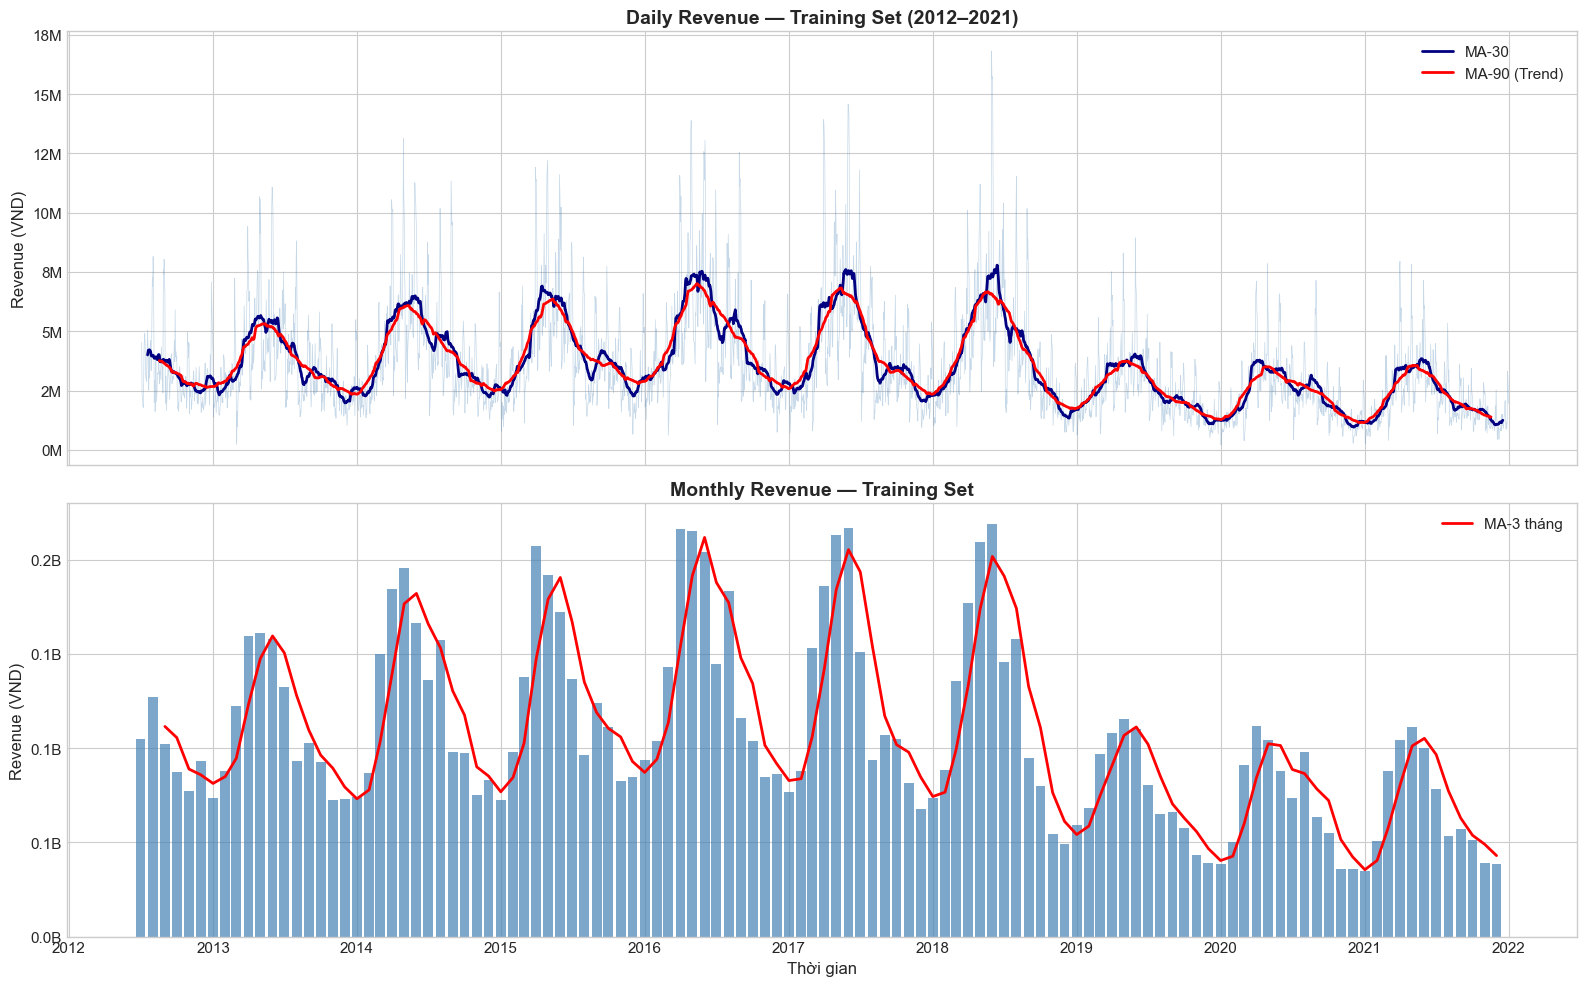

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# --- Daily Revenue ---
ax = axes[0]
ax.plot(daily_revenue['date'], daily_revenue['revenue'], alpha=0.3, color='steelblue', linewidth=0.5)
# Moving average 30 ngày
ma30 = daily_revenue['revenue'].rolling(30, center=True).mean()
ax.plot(daily_revenue['date'], ma30, color='navy', linewidth=2, label='MA-30')
# Moving average 90 ngày
ma90 = daily_revenue['revenue'].rolling(90, center=True).mean()
ax.plot(daily_revenue['date'], ma90, color='red', linewidth=2, label='MA-90 (Trend)')
ax.set_title('Daily Revenue — Training Set (2012–2021)', fontweight='bold')
ax.set_ylabel('Revenue (VND)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# --- Monthly Revenue ---
ax = axes[1]
ax.bar(monthly_revenue['date'], monthly_revenue['revenue'], width=25, color='steelblue', alpha=0.7)
ax.plot(monthly_revenue['date'], monthly_revenue['revenue'].rolling(3).mean(), 
        color='red', linewidth=2, label='MA-3 tháng')
ax.set_title('Monthly Revenue — Training Set', fontweight='bold')
ax.set_ylabel('Revenue (VND)')
ax.set_xlabel('Thời gian')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

plt.tight_layout()
plt.show()

**Phân tích Xu hướng & Biến động Doanh thu (2012–2021)**

**1. Descriptive: Phân đoạn chu kỳ tăng trưởng**
Dựa trên quan sát đường trung bình động (MA-90) và dữ liệu gộp tháng, chu kỳ doanh thu được chia làm 3 giai đoạn chính:
* **Giai đoạn Tăng trưởng & Đạt đỉnh (2013 – 2018):** Doanh thu duy trì xu hướng tăng tiến (Up-trend) vững chắc. Các đỉnh mùa vụ (seasonal peaks) sau cao hơn trước, đạt quy mô lớn nhất vào giai đoạn 2016–2018 (~1.69 tỷ VNĐ/năm).
* **Giai đoạn Đứt gãy xu hướng (2019):** Xuất hiện sự sụt giảm đột ngột và nghiêm trọng (Cliff-edge drop). Doanh thu năm 2019 giảm mạnh **-38.8%** so với cùng kỳ, đánh dấu một điểm gãy cấu trúc (Structural Break) thay vì biến động mùa vụ thông thường.
* **Giai đoạn Suy thoái & Đi ngang (2020 – 2021):** Doanh thu thiết lập mức sàn mới thấp hơn đáng kể so với quá khứ, dao động quanh mức ~805 triệu VNĐ, cho thấy tác động tiêu cực dài hạn từ biến cố năm 2019.

**2. Diagnostic: Đặc tính chuỗi thời gian**
* **Tính mùa vụ (Seasonality):** Biểu đồ cột (Monthly) và đường MA-30 cho thấy tính chu kỳ năm cực kỳ mạnh mẽ với biên độ lớn. Doanh thu thường đạt đỉnh nhọn vào một thời điểm cố định trong năm và rơi sâu ngay sau đó.
* **Độ mạnh xu hướng (Trend Strength):** Chỉ số STL đạt **0.7143**, khẳng định thành phần Xu hướng có tác động trọng yếu đến dữ liệu, đủ lớn để cần được xử lý riêng biệt khi xây dựng mô hình.
* **Biến cố ngoại lai:** Sự sụt giảm năm 2019 được nhận diện là một cú sốc ngoại sinh (External Shock) gây thay đổi hoàn toàn độ dốc của đường xu hướng dài hạn.

> **Kết luận & Khuyến nghị Model:**
> * **Lựa chọn mô hình:** Tránh các mô hình dự báo tuyến tính đơn giản. Khuyến nghị sử dụng **Prophet** (ưu tiên khả năng tự phát hiện `changepoints`) hoặc **SARIMA** (với differencing bậc 1 cho cả Trend và Seasonality).
> * **Xử lý dữ liệu:** Cần thực hiện **Detrending** hoặc **Scaling** lại giai đoạn từ 2019 trở đi nếu muốn dự báo ngắn hạn, nhằm tránh việc mô hình bị nhiễu bởi dữ liệu tăng trưởng quá cao trong giai đoạn 2013-2018.

### 2.2 Year-over-Year Comparison

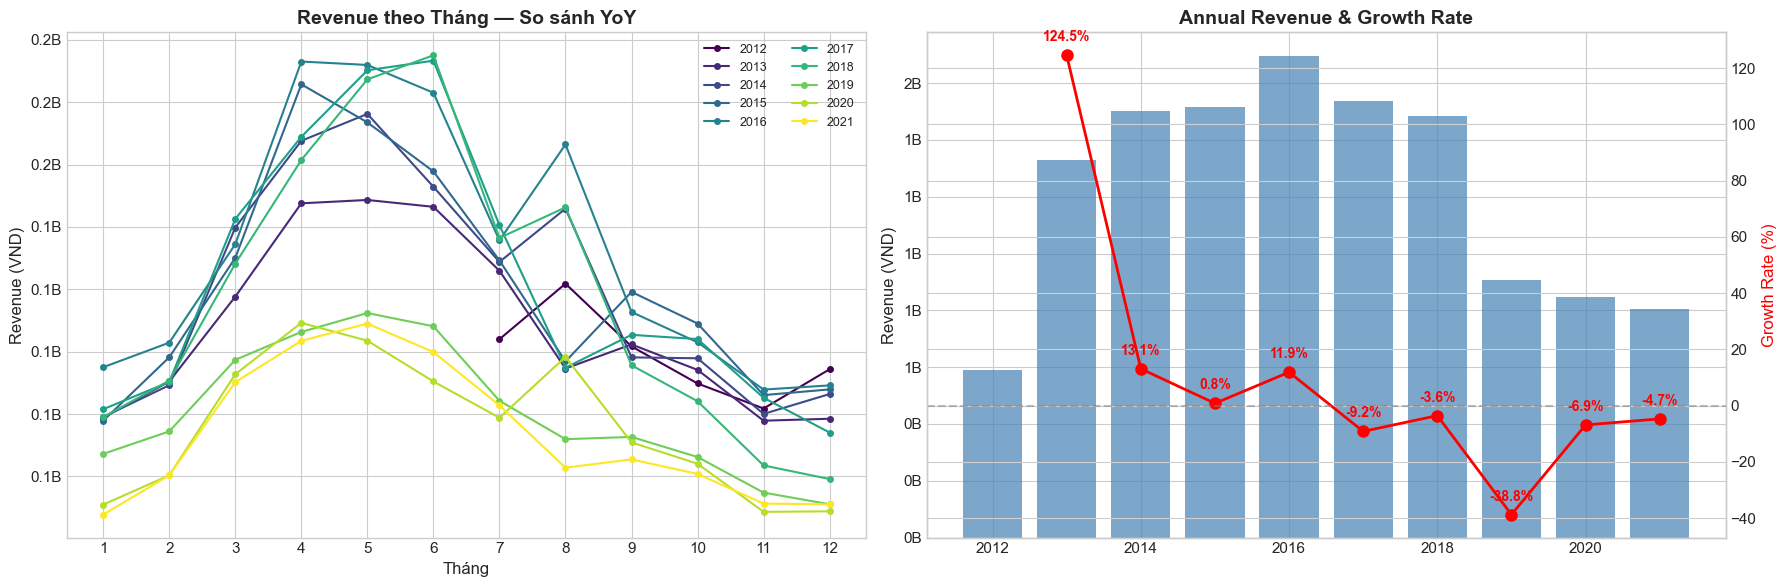


Annual Revenue Summary:
   2012:     591,772,488 VND  |  YoY: N/A
   2013:   1,328,788,168 VND  |  YoY: +124.5%
   2014:   1,502,606,417 VND  |  YoY: +13.1%
   2015:   1,514,458,967 VND  |  YoY: +0.8%
   2016:   1,694,236,037 VND  |  YoY: +11.9%
   2017:   1,538,820,736 VND  |  YoY: -9.2%
   2018:   1,483,790,954 VND  |  YoY: -3.6%
   2019:     908,468,370 VND  |  YoY: -38.8%
   2020:     845,902,936 VND  |  YoY: -6.9%
   2021:     805,930,488 VND  |  YoY: -4.7%


In [6]:
# === Year-over-Year Analysis ===
daily_revenue['year'] = daily_revenue['date'].dt.year
daily_revenue['month'] = daily_revenue['date'].dt.month
daily_revenue['day_of_year'] = daily_revenue['date'].dt.dayofyear

# Monthly revenue by year
monthly_by_year = daily_revenue.groupby(['year', 'month'])['revenue'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Monthly overlay ---
ax = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, daily_revenue['year'].nunique()))
for i, (year, grp) in enumerate(monthly_by_year.groupby('year')):
    ax.plot(grp['month'], grp['revenue'], marker='o', markersize=4, 
            label=str(year), color=colors[i], linewidth=1.5)
ax.set_title('Revenue theo Tháng — So sánh YoY', fontweight='bold')
ax.set_xlabel('Tháng')
ax.set_ylabel('Revenue (VND)')
ax.set_xticks(range(1, 13))
ax.legend(ncol=2, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

# --- Annual growth ---
ax = axes[1]
annual = daily_revenue.groupby('year')['revenue'].sum()
growth = annual.pct_change() * 100
colors_bar = ['green' if g >= 0 else 'red' for g in growth.values]
bars = ax.bar(annual.index, annual.values, color='steelblue', alpha=0.7)
ax.set_title('Annual Revenue & Growth Rate', fontweight='bold')
ax.set_ylabel('Revenue (VND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.0f}B'))

# Add growth rate labels
ax2 = ax.twinx()
ax2.plot(growth.index, growth.values, 'ro-', linewidth=2, markersize=8)
ax2.set_ylabel('Growth Rate (%)', color='red')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
for x, y in zip(growth.index, growth.values):
    if not np.isnan(y):
        ax2.annotate(f'{y:.1f}%', (x, y), textcoords='offset points', 
                     xytext=(0, 10), ha='center', fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nAnnual Revenue Summary:')
for year in annual.index:
    g = f'{growth[year]:+.1f}%' if not np.isnan(growth[year]) else 'N/A'
    print(f'   {year}: {annual[year]:>15,.0f} VND  |  YoY: {g}')

### 2.3 Seasonal Decomposition (STL)

STL (Seasonal and Trend decomposition using Loess) phân tách chuỗi thời gian thành 3 thành phần:
- **Trend:** Xu hướng dài hạn
- **Seasonal:** Mẫu lặp theo chu kỳ (tháng/quý)
- **Residual:** Phần dư (noise + bất thường)

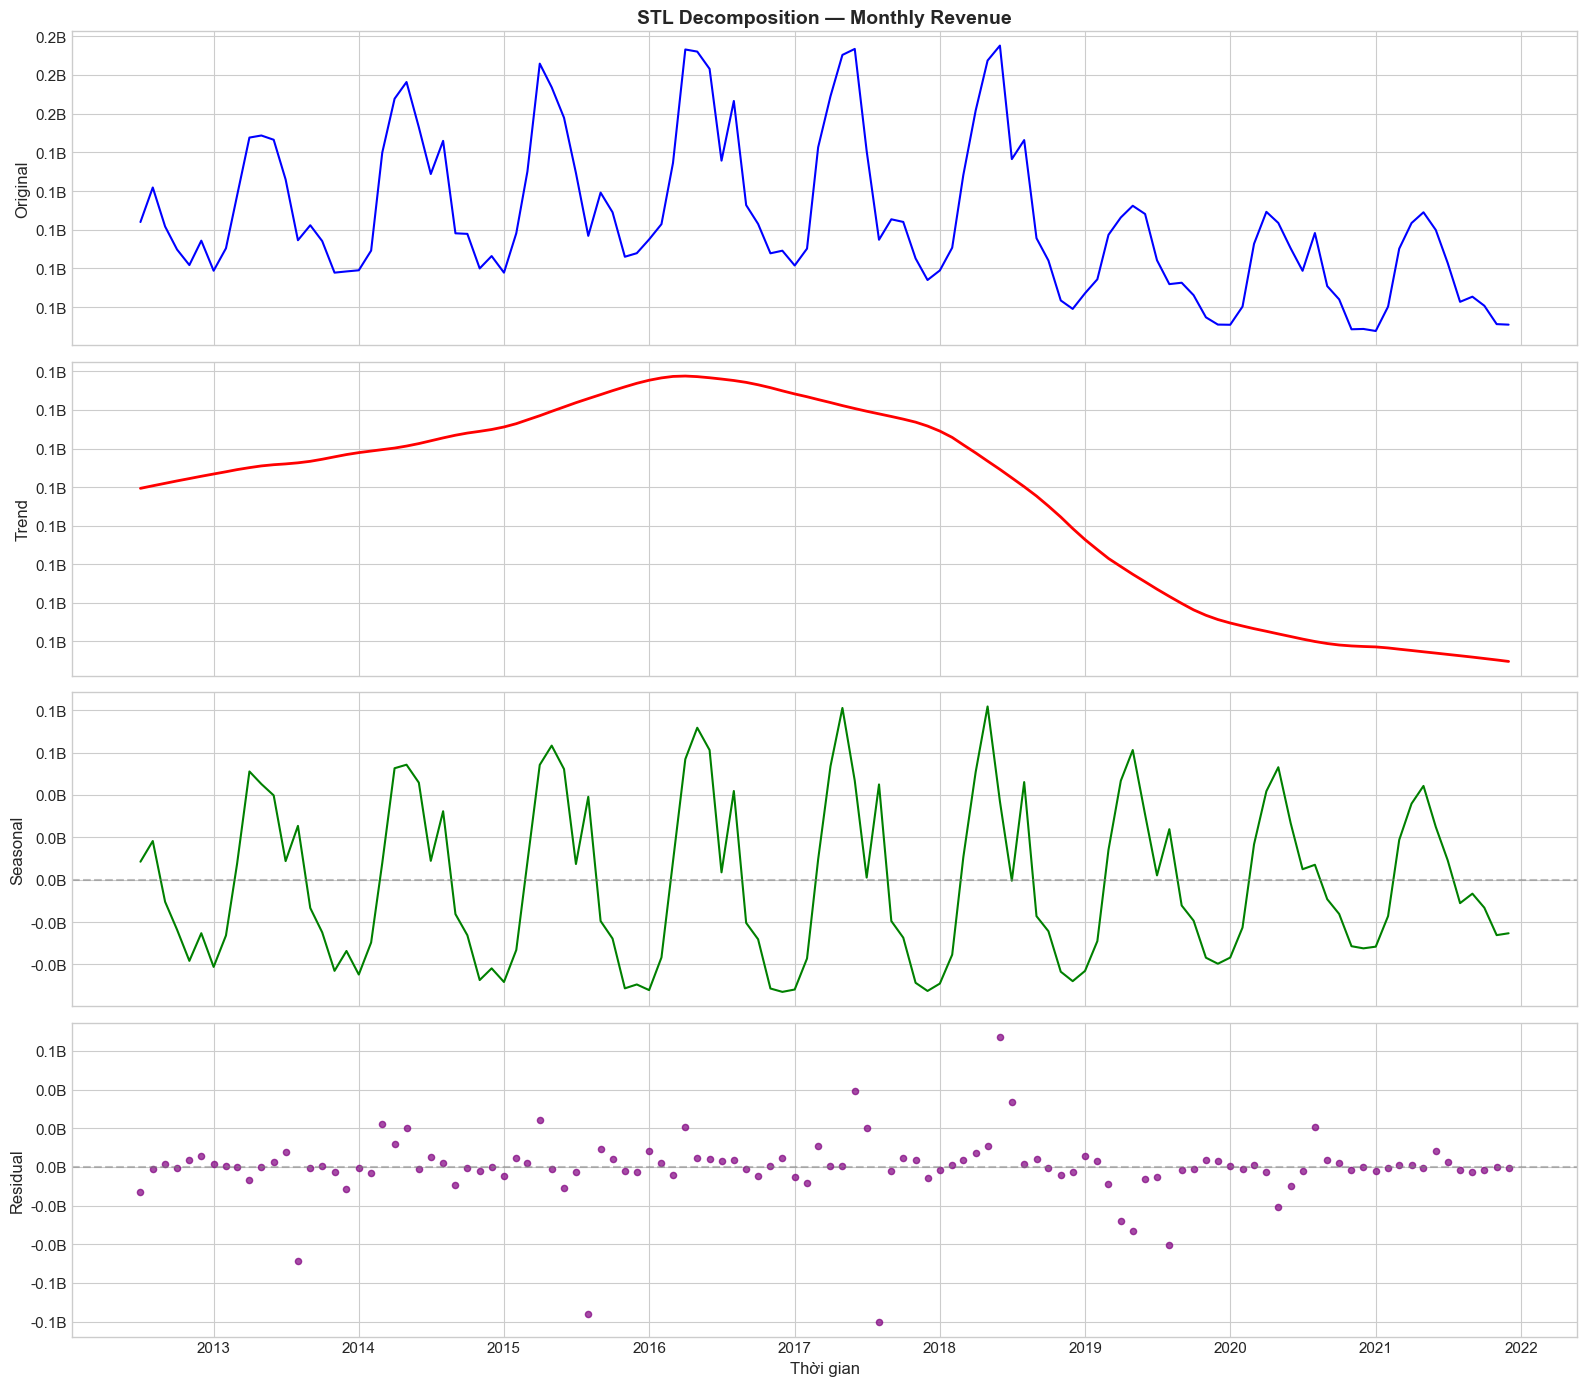


STL Decomposition Results:
   Seasonal Strength: 0.8297 (>0.64: strong seasonality)
   Trend Strength:    0.7143 (>0.64: strong trend)
   STRONG seasonality → Nên dùng model có seasonal component (SARIMA, Prophet)
   STRONG trend → Cần differencing hoặc detrending


In [7]:
# === STL Decomposition — Monthly Revenue ===
monthly_ts = monthly_revenue.set_index('date')['revenue']

# STL decomposition (period=12 for monthly data)
stl = STL(monthly_ts, period=12, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

# Original
axes[0].plot(monthly_ts.index, monthly_ts.values, 'b-', linewidth=1.5)
axes[0].set_title('STL Decomposition — Monthly Revenue', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Original')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

# Trend
axes[1].plot(result.trend.index, result.trend.values, 'r-', linewidth=2)
axes[1].set_ylabel('Trend')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

# Seasonal
axes[2].plot(result.seasonal.index, result.seasonal.values, 'g-', linewidth=1.5)
axes[2].set_ylabel('Seasonal')
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

# Residual
axes[3].scatter(result.resid.index, result.resid.values, c='purple', s=20, alpha=0.7)
axes[3].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Thời gian')
axes[3].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

plt.tight_layout()
plt.show()

# === Seasonal Strength ===
var_resid = np.var(result.resid.dropna())
var_seasonal_resid = np.var(result.seasonal.dropna() + result.resid.dropna())
seasonal_strength = 1 - var_resid / var_seasonal_resid if var_seasonal_resid > 0 else 0

var_trend_resid = np.var(result.trend.dropna() + result.resid.dropna())
trend_strength = 1 - var_resid / var_trend_resid if var_trend_resid > 0 else 0

print(f'\nSTL Decomposition Results:')
print(f'   Seasonal Strength: {max(0, seasonal_strength):.4f} (>0.64: strong seasonality)')
print(f'   Trend Strength:    {max(0, trend_strength):.4f} (>0.64: strong trend)')

if seasonal_strength > 0.64:
    print('   STRONG seasonality → Nên dùng model có seasonal component (SARIMA, Prophet)')
else:
    print('   Weak seasonality → Seasonal component có thể không cần thiết')

if trend_strength > 0.64:
    print('   STRONG trend → Cần differencing hoặc detrending')
else:
    print('   Weak trend → Trend component nhẹ')

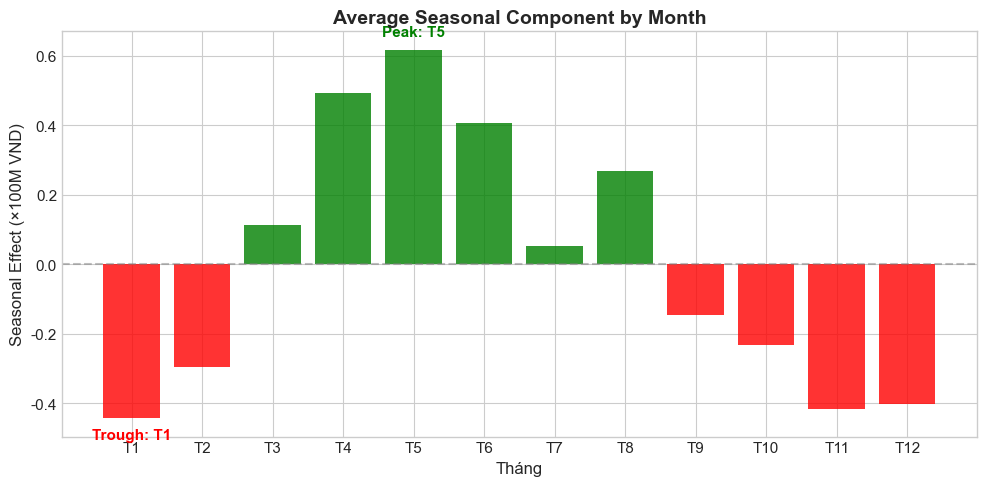


Seasonal Pattern:
   Peak month:   Tháng 5 (seasonal effect: +61,778,171)
   Trough month: Tháng 1 (seasonal effect: -44,315,367)


In [8]:
# === Seasonal Pattern Detail ===
seasonal_by_month = result.seasonal.groupby(result.seasonal.index.month).mean()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if v >= 0 else 'red' for v in seasonal_by_month.values]
ax.bar(seasonal_by_month.index, seasonal_by_month.values, color=colors, alpha=0.8)
ax.set_title('Average Seasonal Component by Month', fontweight='bold')
ax.set_xlabel('Tháng')
ax.set_ylabel('Seasonal Effect (VND)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12'])
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e8:.1f}'))
ax.set_ylabel('Seasonal Effect (×100M VND)')

# Annotate peak/trough
peak_month = seasonal_by_month.idxmax()
trough_month = seasonal_by_month.idxmin()
ax.annotate(f'Peak: T{peak_month}', (peak_month, seasonal_by_month[peak_month]),
            textcoords='offset points', xytext=(0, 10), ha='center', fontweight='bold', color='green')
ax.annotate(f'Trough: T{trough_month}', (trough_month, seasonal_by_month[trough_month]),
            textcoords='offset points', xytext=(0, -15), ha='center', fontweight='bold', color='red')

plt.tight_layout()
plt.show()

print(f'\nSeasonal Pattern:')
print(f'   Peak month:   Tháng {peak_month} (seasonal effect: {seasonal_by_month[peak_month]:+,.0f})')
print(f'   Trough month: Tháng {trough_month} (seasonal effect: {seasonal_by_month[trough_month]:+,.0f})')

### 2.4 Stationarity Tests (ADF & KPSS)

Kiểm tra tính dừng (stationarity) — **điều kiện tiên quyết** cho các mô hình ARIMA/SARIMA.

| Test | H₀ | Kết luận dừng khi |
|------|------|-------------------|
| **ADF** (Augmented Dickey-Fuller) | Chuỗi có unit root (non-stationary) | p-value < 0.05 → Reject H₀ → Dừng |
| **KPSS** (Kwiatkowski-Phillips-Schmidt-Shin) | Chuỗi dừng | p-value > 0.05 → Fail to reject H₀ → Dừng |

In [9]:
def stationarity_test(series, series_name='Series'):
    """Perform ADF and KPSS tests and print results."""
    print(f'\n{"="*60}')
    print(f'STATIONARITY TEST: {series_name}')
    print(f'{"="*60}')
    
    # ADF Test
    adf_result = adfuller(series.dropna(), autolag='AIC')
    print(f'\nADF Test (H₀: Non-stationary):')
    print(f'   Test Statistic: {adf_result[0]:.4f}')
    print(f'   p-value:        {adf_result[1]:.6f}')
    print(f'   Critical Values:')
    for key, val in adf_result[4].items():
        print(f'      {key}: {val:.4f}')
    
    adf_stationary = adf_result[1] < 0.05
    print(f'   → Kết luận: {"DỪNG (Stationary)" if adf_stationary else "KHÔNG DỪNG (Non-stationary)"}')
    
    # KPSS Test
    kpss_result = kpss(series.dropna(), regression='ct', nlags='auto')
    print(f'\nKPSS Test (H₀: Stationary):')
    print(f'   Test Statistic: {kpss_result[0]:.4f}')
    print(f'   p-value:        {kpss_result[1]:.6f}')
    print(f'   Critical Values:')
    for key, val in kpss_result[3].items():
        print(f'      {key}: {val:.4f}')
    
    kpss_stationary = kpss_result[1] > 0.05
    print(f'   → Kết luận: {"DỪNG (Stationary)" if kpss_stationary else "KHÔNG DỪNG (Non-stationary)"}')
    
    # Combined conclusion
    print(f'\nTỔNG HỢP:')
    if adf_stationary and kpss_stationary:
        print('   Cả 2 tests đều xác nhận: DỪNG → Có thể dùng ARIMA(p,0,q)')
    elif not adf_stationary and not kpss_stationary:
        print('   Cả 2 tests đều xác nhận: KHÔNG DỪNG → Cần differencing (d≥1)')
    elif adf_stationary and not kpss_stationary:
        print('   Kết quả mâu thuẫn: Có thể Trend-stationary → Thử detrending')
    else:
        print('   Kết quả mâu thuẫn: Có thể Difference-stationary → Thử differencing')
    
    return adf_stationary, kpss_stationary

# Test trên Monthly Revenue
adf_stat, kpss_stat = stationarity_test(monthly_ts, 'Monthly Revenue (Original)')


STATIONARITY TEST: Monthly Revenue (Original)

ADF Test (H₀: Non-stationary):
   Test Statistic: -0.3298
   p-value:        0.921178
   Critical Values:
      1%: -3.4975
      5%: -2.8909
      10%: -2.5824
   → Kết luận: KHÔNG DỪNG (Non-stationary)

KPSS Test (H₀: Stationary):
   Test Statistic: 0.1861
   p-value:        0.021206
   Critical Values:
      10%: 0.1190
      5%: 0.1460
      2.5%: 0.1760
      1%: 0.2160
   → Kết luận: KHÔNG DỪNG (Non-stationary)

TỔNG HỢP:
   Cả 2 tests đều xác nhận: KHÔNG DỪNG → Cần differencing (d≥1)


In [10]:
# === Nếu không dừng → Thử differencing ===
if not (adf_stat and kpss_stat):
    print('\nThử First Differencing (d=1)...')
    monthly_diff1 = monthly_ts.diff().dropna()
    adf1, kpss1 = stationarity_test(monthly_diff1, 'Monthly Revenue (1st Diff)')
    
    if not (adf1 and kpss1):
        print('\nThử Second Differencing (d=2)...')
        monthly_diff2 = monthly_diff1.diff().dropna()
        adf2, kpss2 = stationarity_test(monthly_diff2, 'Monthly Revenue (2nd Diff)')
    
    # Seasonal differencing
    print('\nThử Seasonal Differencing (D=1, s=12)...')
    monthly_sdiff = monthly_ts.diff(12).dropna()
    adf_s, kpss_s = stationarity_test(monthly_sdiff, 'Monthly Revenue (Seasonal Diff, s=12)')
else:
    print('\nChuỗi đã dừng, không cần differencing.')


Thử First Differencing (d=1)...

STATIONARITY TEST: Monthly Revenue (1st Diff)

ADF Test (H₀: Non-stationary):
   Test Statistic: -2.5739
   p-value:        0.098523
   Critical Values:
      1%: -3.4982
      5%: -2.8912
      10%: -2.5826
   → Kết luận: KHÔNG DỪNG (Non-stationary)

KPSS Test (H₀: Stationary):
   Test Statistic: 0.0132
   p-value:        0.100000
   Critical Values:
      10%: 0.1190
      5%: 0.1460
      2.5%: 0.1760
      1%: 0.2160
   → Kết luận: DỪNG (Stationary)

TỔNG HỢP:
   Kết quả mâu thuẫn: Có thể Difference-stationary → Thử differencing

Thử Second Differencing (d=2)...

STATIONARITY TEST: Monthly Revenue (2nd Diff)

ADF Test (H₀: Non-stationary):
   Test Statistic: -10.2679
   p-value:        0.000000
   Critical Values:
      1%: -3.4982
      5%: -2.8912
      10%: -2.5826
   → Kết luận: DỪNG (Stationary)

KPSS Test (H₀: Stationary):
   Test Statistic: 0.0178
   p-value:        0.100000
   Critical Values:
      10%: 0.1190
      5%: 0.1460
      2.5%: 

C:\Users\admin\AppData\Local\Temp\ipykernel_22220\635953094.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='ct', nlags='auto')
C:\Users\admin\AppData\Local\Temp\ipykernel_22220\635953094.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='ct', nlags='auto')


### 2.5 ACF & PACF — Xác định bậc p, q cho ARIMA

- **ACF (Autocorrelation Function):** Giúp xác định bậc `q` (MA order)
- **PACF (Partial Autocorrelation Function):** Giúp xác định bậc `p` (AR order)

| Pattern | ACF | PACF | Gợi ý model |
|---------|-----|------|-------------|
| AR(p) | Giảm dần | Cutoff tại lag p | ARIMA(p,d,0) |
| MA(q) | Cutoff tại lag q | Giảm dần | ARIMA(0,d,q) |
| ARMA | Giảm dần | Giảm dần | ARIMA(p,d,q) |

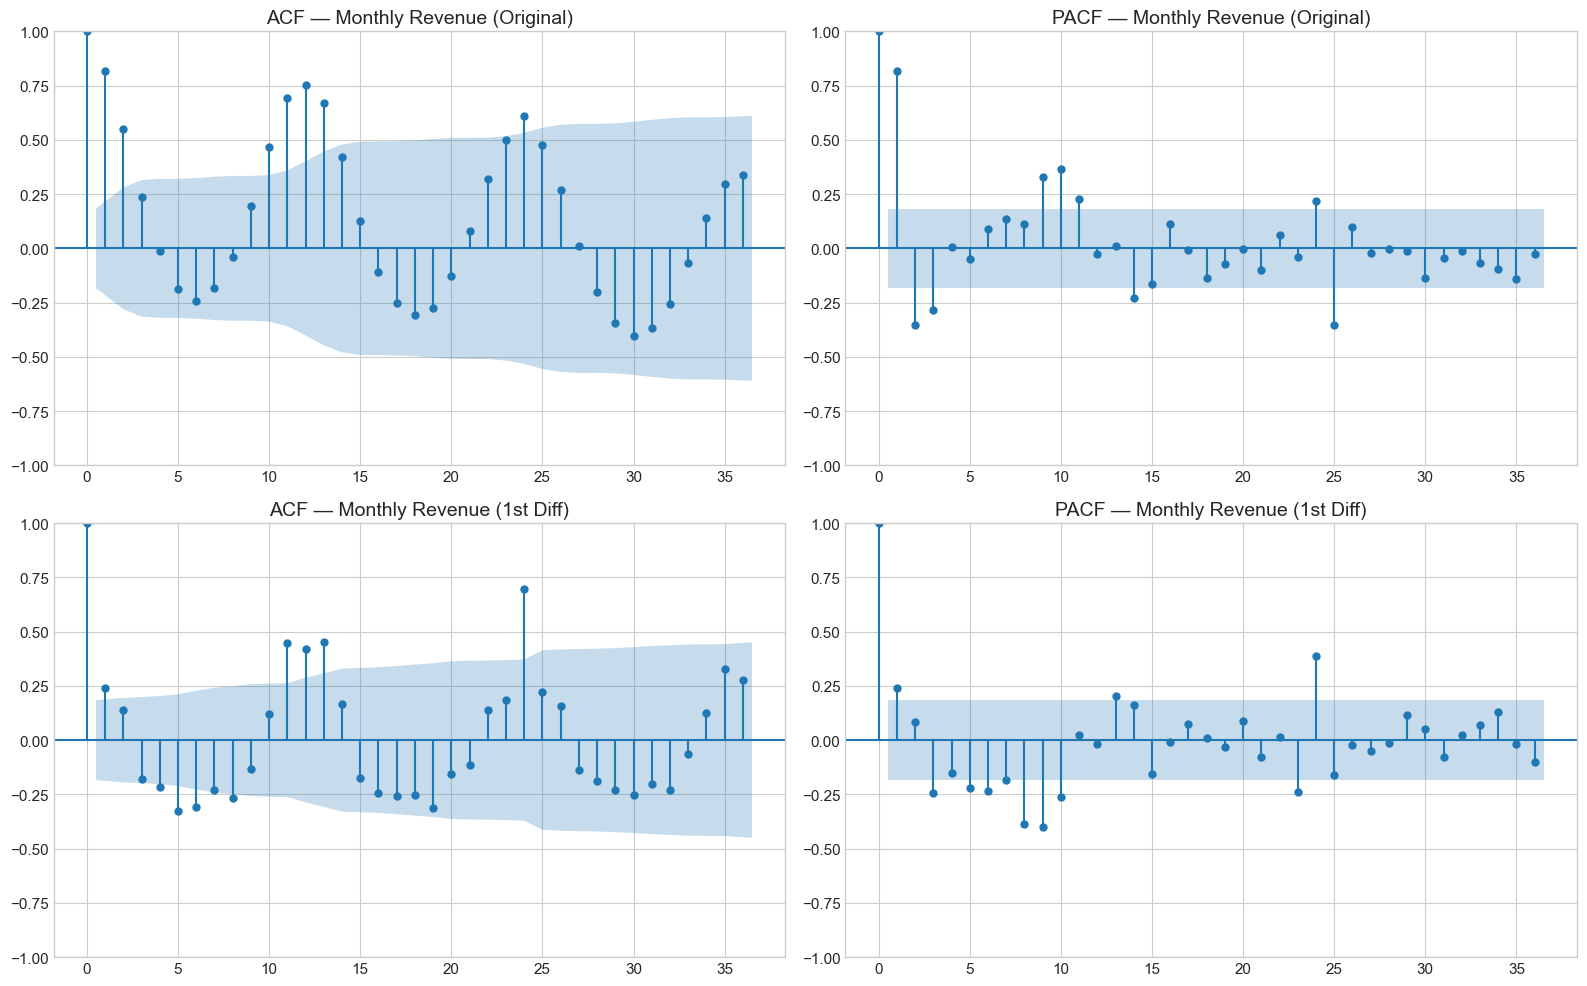


Hướng dẫn đọc ACF/PACF:
   - Các lag vượt ngoài vùng xanh (confidence interval) là significant
   - ACF có spike tại lag 12, 24 → mùa vụ chu kỳ 12 tháng
   - PACF cutoff sớm → gợi ý bậc p cho AR component


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Original series
plot_acf(monthly_ts.dropna(), ax=axes[0, 0], lags=36, title='ACF — Monthly Revenue (Original)')
plot_pacf(monthly_ts.dropna(), ax=axes[0, 1], lags=36, title='PACF — Monthly Revenue (Original)', method='ywm')

# After differencing (if needed)
try:
    diff_series = monthly_ts.diff().dropna()
    plot_acf(diff_series, ax=axes[1, 0], lags=36, title='ACF — Monthly Revenue (1st Diff)')
    plot_pacf(diff_series, ax=axes[1, 1], lags=36, title='PACF — Monthly Revenue (1st Diff)', method='ywm')
except:
    axes[1, 0].text(0.5, 0.5, 'Không đủ dữ liệu', ha='center', va='center', transform=axes[1,0].transAxes)
    axes[1, 1].text(0.5, 0.5, 'Không đủ dữ liệu', ha='center', va='center', transform=axes[1,1].transAxes)

plt.tight_layout()
plt.show()

print('\nHướng dẫn đọc ACF/PACF:')
print('   - Các lag vượt ngoài vùng xanh (confidence interval) là significant')
print('   - ACF có spike tại lag 12, 24 → mùa vụ chu kỳ 12 tháng')
print('   - PACF cutoff sớm → gợi ý bậc p cho AR component')

### 2.6 Day-of-Week & Intra-Month Patterns

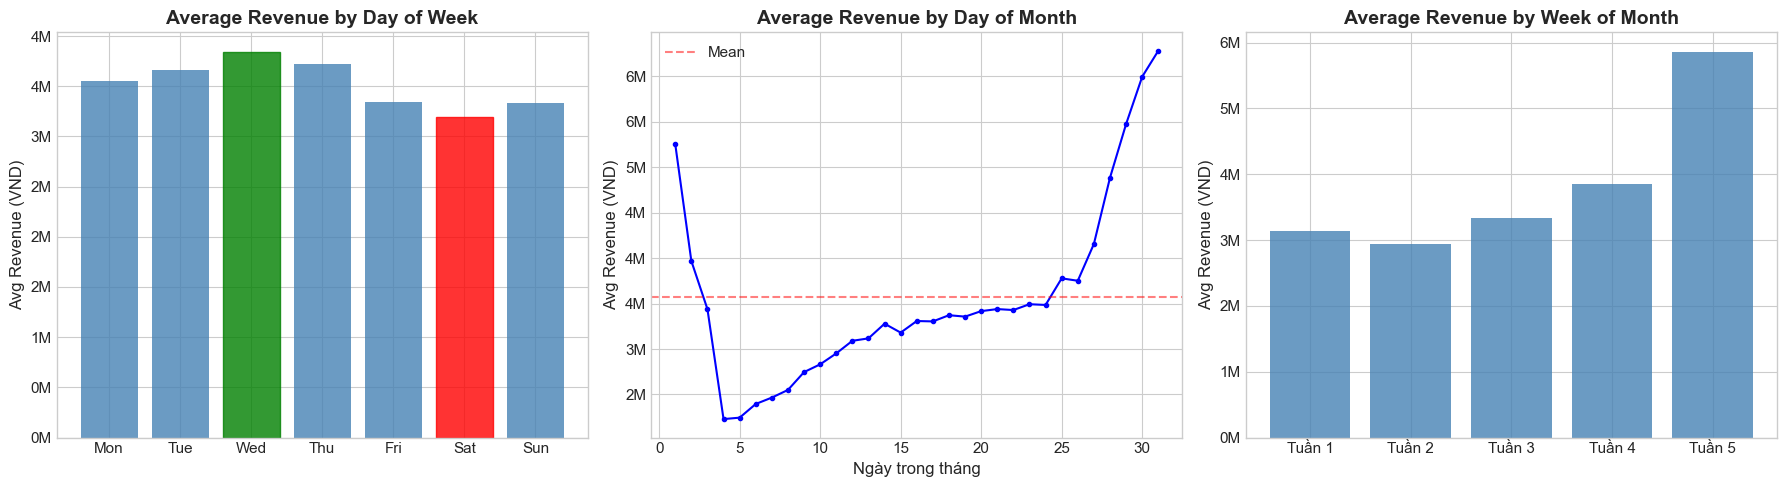


Day-of-Week Pattern:
   Highest: Wed (3,844,937 VND avg)
   Lowest:  Sat (3,191,272 VND avg)
   Ratio (Max/Min): 1.20x


In [12]:
daily_revenue['dow'] = daily_revenue['date'].dt.dayofweek  # 0=Mon, 6=Sun
daily_revenue['day'] = daily_revenue['date'].dt.day
daily_revenue['week_of_month'] = (daily_revenue['day'] - 1) // 7 + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Day of Week
dow_rev = daily_revenue.groupby('dow')['revenue'].mean()
ax = axes[0]
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
bars = ax.bar(dow_labels, dow_rev.values, color='steelblue', alpha=0.8)
ax.set_title('Average Revenue by Day of Week', fontweight='bold')
ax.set_ylabel('Avg Revenue (VND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
# Highlight max/min
max_dow = dow_rev.idxmax()
min_dow = dow_rev.idxmin()
bars[max_dow].set_color('green')
bars[min_dow].set_color('red')

# Day of Month
dom_rev = daily_revenue.groupby('day')['revenue'].mean()
ax = axes[1]
ax.plot(dom_rev.index, dom_rev.values, 'b-o', markersize=3)
ax.axhline(y=dom_rev.mean(), color='red', linestyle='--', alpha=0.5, label='Mean')
ax.set_title('Average Revenue by Day of Month', fontweight='bold')
ax.set_xlabel('Ngày trong tháng')
ax.set_ylabel('Avg Revenue (VND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.legend()

# Week of Month
wom_rev = daily_revenue.groupby('week_of_month')['revenue'].mean()
ax = axes[2]
wom_labels = ['Tuần 1', 'Tuần 2', 'Tuần 3', 'Tuần 4', 'Tuần 5']
ax.bar(wom_labels[:len(wom_rev)], wom_rev.values, color='steelblue', alpha=0.8)
ax.set_title('Average Revenue by Week of Month', fontweight='bold')
ax.set_ylabel('Avg Revenue (VND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.tight_layout()
plt.show()

print(f'\nDay-of-Week Pattern:')
print(f'   Highest: {dow_labels[max_dow]} ({dow_rev[max_dow]:,.0f} VND avg)')
print(f'   Lowest:  {dow_labels[min_dow]} ({dow_rev[min_dow]:,.0f} VND avg)')
print(f'   Ratio (Max/Min): {dow_rev[max_dow]/dow_rev[min_dow]:.2f}x')

#### Tổng hợp Section 2 — Target Deep Dive

| Aspect | Finding (Insight Thực Tế) | Implication for Forecasting (Hành Động) |
|--------|---------------------------|----------------------------|
| **Trend** | Doanh thu đạt đỉnh 2016, chạm đáy/giảm mạnh 2019 (-38.8%) và dốc xuống nhẹ đến 2021. Trend Strength = 0.7143. | Chắc chắn cần Differencing hoặc Detrending. Các model weight data gần đây (như Exponential Smoothing) hoặc LSTM/Prophet sẽ fit tốt hơn. |
| **Seasonality** | Tính mùa vụ RẤT MẠNH (Seasonal Strength = 0.8297). Mùa mua sắm tạo đỉnh vào **Tháng 5** (+61.7 triệu/tháng) và đáy ở **Tháng 1** (-44.3 triệu/tháng). | Tiền đề để sử dụng các Seasonal model như SARIMA, Prophet có daily/yearly seasonality components. |
| **Stationarity** | Original data KHÔNG DỪNG (cả ADF và KPSS test). Sau khi Differencing D=2, dữ liệu mới đạt điểm stationarity an toàn. | `d=1` hoặc `d=2` cho mô hình ARIMA. Quá trình chia Train/Val cần cẩn thận mốc 2019. |
| **ACF/PACF** | Spike mạnh lặp lại mỗi 12 độ trễ (12, 24, 36) ở biểu đồ ACF. PACF báo hiệu cắt sớm. | Chu kỳ độ trễ theo năm (s=12). Hỗ trợ xác nhận thông số p, q cho SARIMA. |
| **Day-of-Week** | Thứ 4 cao nhất (3.84 triệu), Thứ 7 thấp nhất (3.19 triệu). Chênh lệch Max/Min ~1.20x | Ở cấp độ Daily forecast, cần bổ sung các biến Dummy/Calendar (DayOfWeek, IsWeekend) để cải thiện độ chuẩn xác. |

> **Hướng đi tiếp theo:** Target `Revenue` là một chuỗi thời gian không dừng, cấu trúc phức tạp và có nhiễu mùa vụ mạnh. Cần ưu tiên các mô hình có cơ chế xử lý Trend (Differencing) kết hợp Seasonality.


---
## 3. Master Data Profiling

Phân tích phân phối đơn biến của các bảng tham chiếu: Products, Customers, Geography.

### 3.1 Products Profiling

In [13]:
print(f'Products Dataset: {len(products)} sản phẩm')
print(f'\n--- Phân bổ theo Category ---')
print(products['category'].value_counts())
print(f'\n--- Phân bổ theo Segment ---')
print(products['segment'].value_counts())
print(f'\n--- Phân bổ theo Size ---')
print(products['size'].value_counts())
print(f'\n--- Thống kê Price & COGS ---')
print(products[['price', 'cogs']].describe())

# Margin analysis
products['margin'] = products['price'] - products['cogs']
products['margin_pct'] = (products['margin'] / products['price']) * 100
print(f'\n--- Gross Margin ---')
print(products[['margin', 'margin_pct']].describe())

Products Dataset: 2412 sản phẩm

--- Phân bổ theo Category ---
category
Streetwear    1320
Outdoor        743
Casual         201
GenZ           148
Name: count, dtype: int64

--- Phân bổ theo Segment ---
segment
Activewear     598
Everyday       405
Performance    347
Balanced       306
Standard       262
Premium        177
All-weather    169
Trendy         148
Name: count, dtype: int64

--- Phân bổ theo Size ---
size
S     603
M     603
L     603
XL    603
Name: count, dtype: int64

--- Thống kê Price & COGS ---
              price          cogs
count   2412.000000   2412.000000
mean    4928.216231   3868.346732
std     4776.737669   3878.584151
min        9.056594      5.183829
25%       59.444924     35.066367
50%     4399.605000   3184.934093
75%     7720.513784   5864.916462
max    40950.000000  38902.500000

--- Gross Margin ---
             margin   margin_pct
count   2412.000000  2412.000000
mean    1059.869500    26.587267
std     1422.068487    15.114823
min        3.872765  

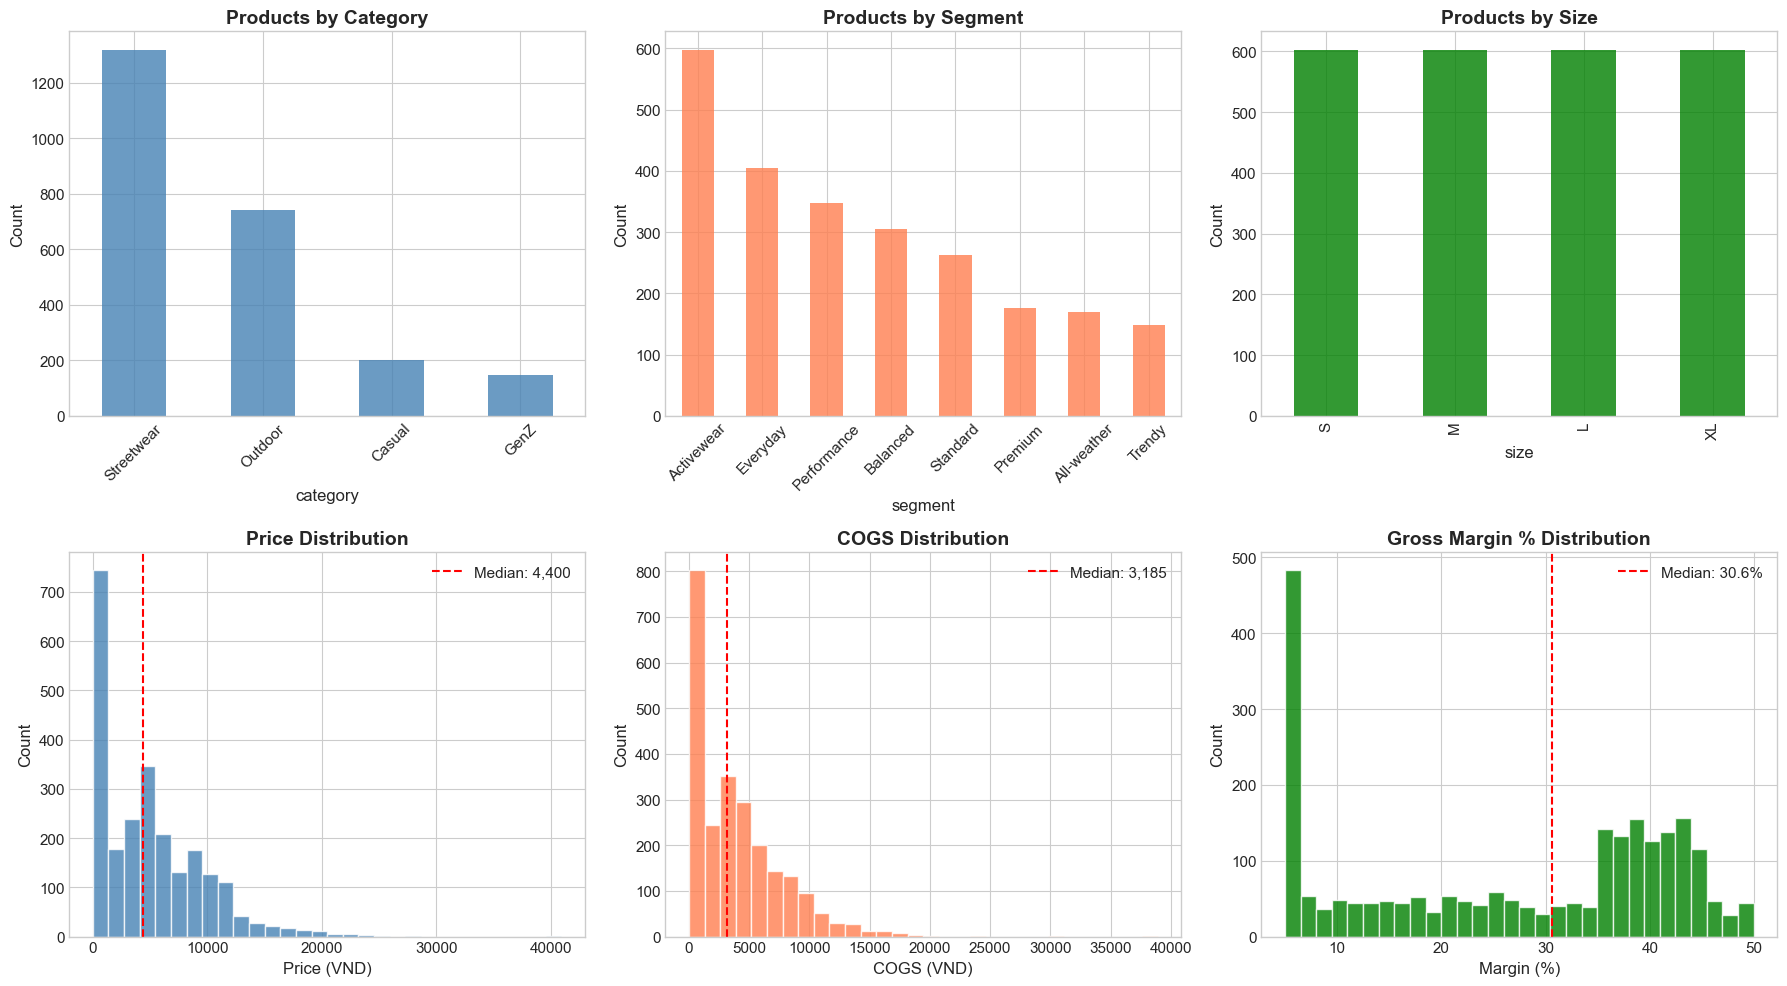

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Category distribution
ax = axes[0, 0]
products['category'].value_counts().plot.bar(ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Products by Category', fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

# Segment distribution
ax = axes[0, 1]
products['segment'].value_counts().plot.bar(ax=ax, color='coral', alpha=0.8)
ax.set_title('Products by Segment', fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

# Size distribution
ax = axes[0, 2]
size_order = ['S', 'M', 'L', 'XL']
size_counts = products['size'].value_counts().reindex(size_order)
size_counts.plot.bar(ax=ax, color='green', alpha=0.8)
ax.set_title('Products by Size', fontweight='bold')
ax.set_ylabel('Count')

# Price distribution
ax = axes[1, 0]
ax.hist(products['price'], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(products['price'].median(), color='red', linestyle='--', label=f'Median: {products["price"].median():,.0f}')
ax.set_title('Price Distribution', fontweight='bold')
ax.set_xlabel('Price (VND)')
ax.set_ylabel('Count')
ax.legend()

# COGS distribution
ax = axes[1, 1]
ax.hist(products['cogs'], bins=30, color='coral', alpha=0.8, edgecolor='white')
ax.axvline(products['cogs'].median(), color='red', linestyle='--', label=f'Median: {products["cogs"].median():,.0f}')
ax.set_title('COGS Distribution', fontweight='bold')
ax.set_xlabel('COGS (VND)')
ax.set_ylabel('Count')
ax.legend()

# Margin % distribution
ax = axes[1, 2]
ax.hist(products['margin_pct'], bins=30, color='green', alpha=0.8, edgecolor='white')
ax.axvline(products['margin_pct'].median(), color='red', linestyle='--', 
           label=f'Median: {products["margin_pct"].median():.1f}%')
ax.set_title('Gross Margin % Distribution', fontweight='bold')
ax.set_xlabel('Margin (%)')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.show()

Price & Margin by Segment:


,n_products,avg_price,avg_cogs,avg_margin_pct
segment,,,,
Activewear,598,2598.1,2034.8,26.6
All-weather,169,3864.7,3008.5,28.4
Balanced,306,9230.2,7230.8,25.8
Everyday,405,7549.2,6007.5,23.6
Performance,347,6572.8,5095.1,26.4
Premium,177,2387.7,1928.3,28.5
Standard,262,2928.6,2259.4,31.3
Trendy,148,2212.8,1745.3,24.1


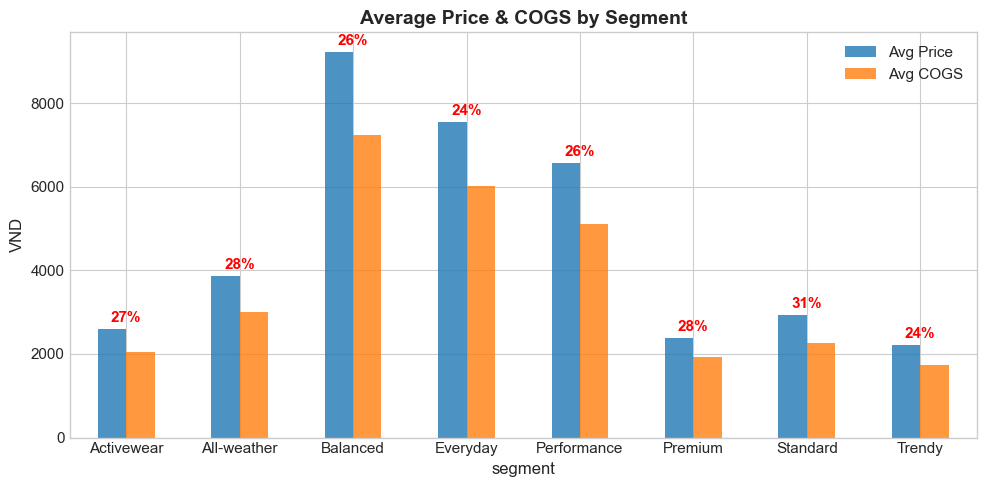

In [15]:
# Segment × Pricing analysis
print('Price & Margin by Segment:')
segment_stats = products.groupby('segment').agg(
    n_products=('product_id', 'count'),
    avg_price=('price', 'mean'),
    avg_cogs=('cogs', 'mean'),
    avg_margin_pct=('margin_pct', 'mean')
).round(1)
display(segment_stats)

fig, ax = plt.subplots(figsize=(10, 5))
segment_stats[['avg_price', 'avg_cogs']].plot.bar(ax=ax, alpha=0.8)
ax.set_title('Average Price & COGS by Segment', fontweight='bold')
ax.set_ylabel('VND')
ax.tick_params(axis='x', rotation=0)
# Add margin labels
for i, (idx, row) in enumerate(segment_stats.iterrows()):
    ax.annotate(f'{row.avg_margin_pct:.0f}%', (i, row.avg_price), 
                textcoords='offset points', xytext=(0, 5), ha='center', fontweight='bold', color='red')
ax.legend(['Avg Price', 'Avg COGS'])
plt.tight_layout()
plt.show()

### 3.2 Customers Profiling

Training Customers: 88,924 / 121,930 tổng


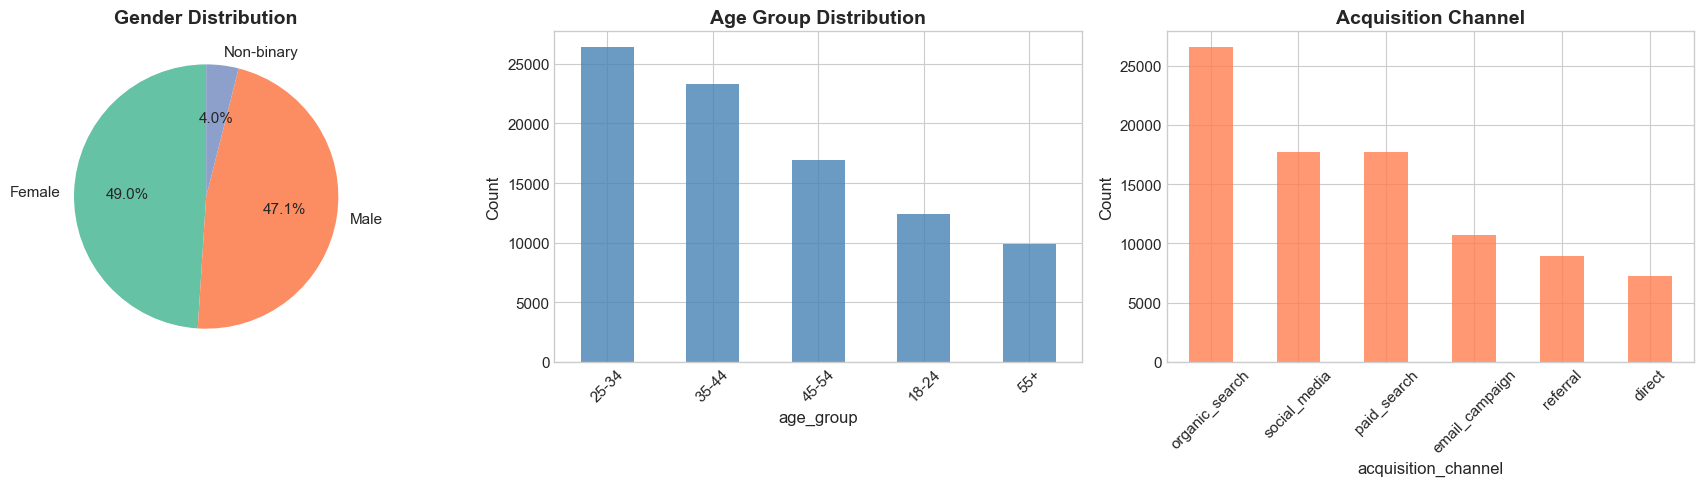

In [16]:
# Chỉ phân tích khách hàng trong training set
train_customer_ids = set(train_orders['customer_id'])
train_customers = customers[customers['customer_id'].isin(train_customer_ids)].copy()

print(f'Training Customers: {len(train_customers):,} / {len(customers):,} tổng')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gender
ax = axes[0]
gender_counts = train_customers['gender'].fillna('Unknown').value_counts()
ax.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90,
       colors=plt.cm.Set2.colors)
ax.set_title('Gender Distribution', fontweight='bold')

# Age Group
ax = axes[1]
age_counts = train_customers['age_group'].fillna('Unknown').value_counts()
age_counts.plot.bar(ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Age Group Distribution', fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

# Acquisition Channel
ax = axes[2]
channel_counts = train_customers['acquisition_channel'].fillna('Unknown').value_counts()
channel_counts.plot.bar(ax=ax, color='coral', alpha=0.8)
ax.set_title('Acquisition Channel', fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

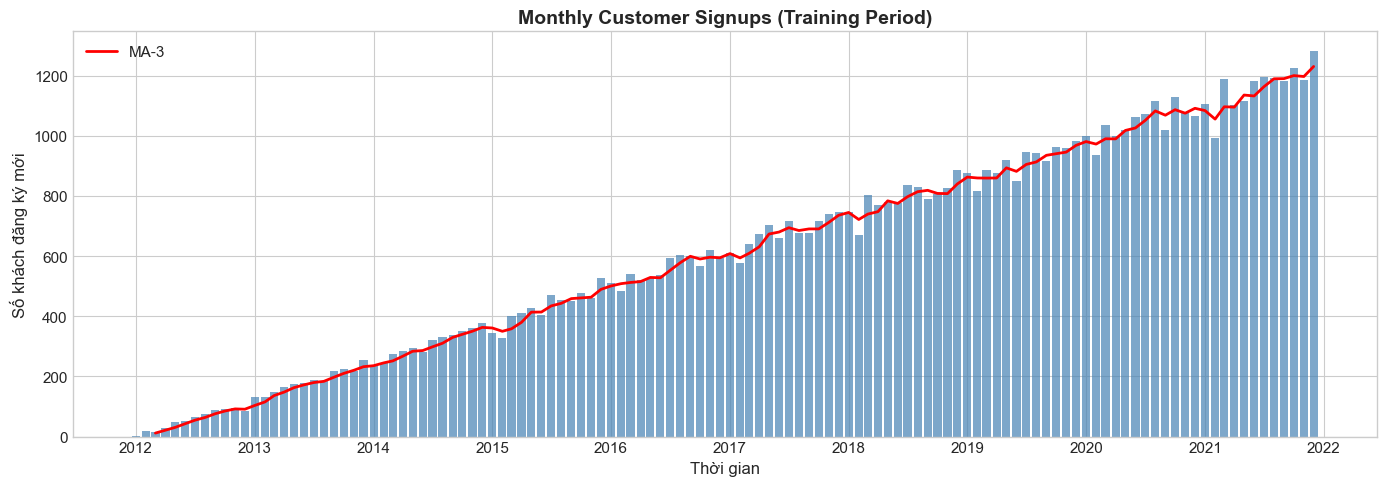


Customer Signup Summary:
   Total signups:     73,504
   Avg signups/month: 613


In [17]:
# === Customer Signup Trend ===
train_signups = train_customers[train_customers['signup_date'] <= TRAIN_END].copy()
monthly_signups = train_signups.set_index('signup_date').resample('MS').size()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly_signups.index, monthly_signups.values, width=25, color='steelblue', alpha=0.7)
ax.plot(monthly_signups.index, monthly_signups.rolling(3).mean(), color='red', linewidth=2, label='MA-3')
ax.set_title('Monthly Customer Signups (Training Period)', fontweight='bold')
ax.set_xlabel('Thời gian')
ax.set_ylabel('Số khách đăng ký mới')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nCustomer Signup Summary:')
print(f'   Total signups:     {len(train_signups):,}')
print(f'   Avg signups/month: {monthly_signups.mean():.0f}')

### 3.3 Geography Profiling

Geography Dataset: 39948 zip codes

--- Regions ---
region
East       18929
Central    14512
West        6507
Name: count, dtype: int64

--- Top 10 Cities by Zip Count ---
city
Cam Pha        1403
Phu Ly         1399
Thai Nguyen    1394
Hanoi          1376
Nam Dinh       1370
Ha Long        1357
Bac Giang      1347
Hai Phong      1346
Bac Ninh       1346
Son Tay        1344
Name: count, dtype: int64


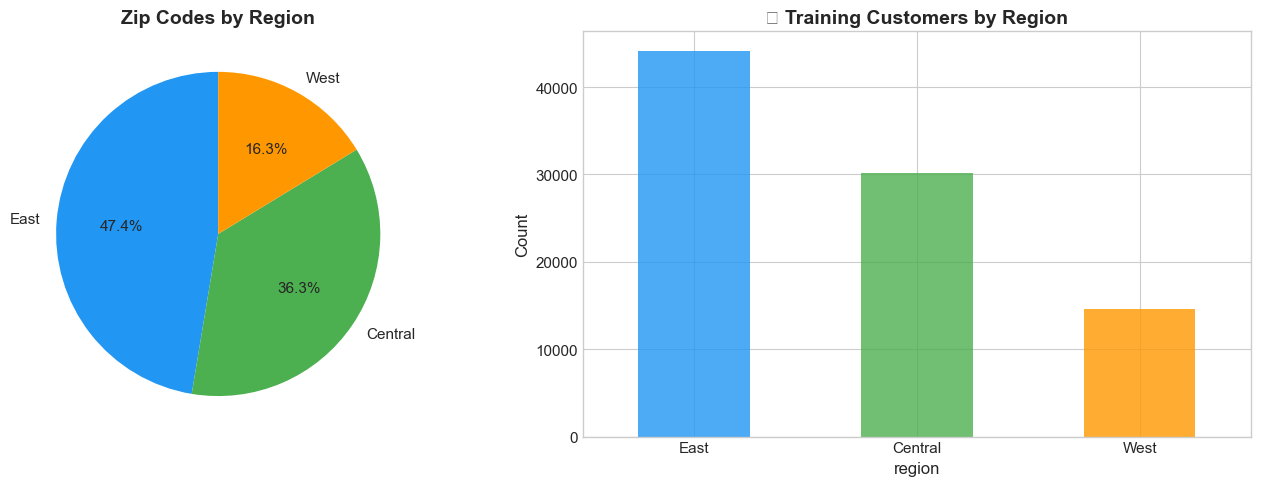

In [18]:
print(f'Geography Dataset: {len(geography)} zip codes')
print(f'\n--- Regions ---')
print(geography['region'].value_counts())
print(f'\n--- Top 10 Cities by Zip Count ---')
print(geography['city'].value_counts().head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Region distribution
ax = axes[0]
geography['region'].value_counts().plot.pie(ax=ax, autopct='%1.1f%%', startangle=90,
                                            colors=['#2196F3', '#4CAF50', '#FF9800'])
ax.set_title('Zip Codes by Region', fontweight='bold')
ax.set_ylabel('')

# Customer distribution by region
ax = axes[1]
cust_geo = train_customers.merge(geography[['zip', 'region']], on='zip', how='left')
cust_region = cust_geo['region'].value_counts()
cust_region.plot.bar(ax=ax, color=['#2196F3', '#4CAF50', '#FF9800'], alpha=0.8)
ax.set_title('👥 Training Customers by Region', fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## 4. Revenue & COGS Distribution

Phân tích phân phối giá trị đơn hàng, doanh thu, và lợi nhuận.

In [19]:
# === Order-level Revenue ===
order_revenue = successful_items.groupby('order_id').agg(
    total_revenue=('revenue', 'sum'),
    total_cogs=('cogs_total', 'sum'),
    total_profit=('gross_profit', 'sum'),
    n_items=('quantity', 'sum'),
    n_products=('product_id', 'nunique'),
    total_discount=('discount_amount', 'sum')
).reset_index()

order_revenue['aov'] = order_revenue['total_revenue']  # Average Order Value
order_revenue['margin_pct'] = (order_revenue['total_profit'] / order_revenue['total_revenue'] * 100)

print('Order Revenue Statistics (Delivered only):')
print(order_revenue[['total_revenue', 'total_cogs', 'total_profit', 'n_items', 'margin_pct']].describe().round(1))

Order Revenue Statistics (Delivered only):
       total_revenue  total_cogs  total_profit   n_items  margin_pct
count       489028.0    489028.0      489028.0  489028.0    489028.0
mean         24977.7     21502.9        3470.4       5.0        13.1
std          22550.0     20122.2        7352.1       2.8        23.3
min            535.2         0.0     -152935.7       1.0     -2186.1
25%           8105.1      6714.7         320.2       3.0         3.8
50%          18017.9     14992.9        1758.3       5.0        12.9
75%          34810.1     29816.6        5298.8       7.0        28.5
max         331570.4    311220.0      126222.7      25.0        97.3


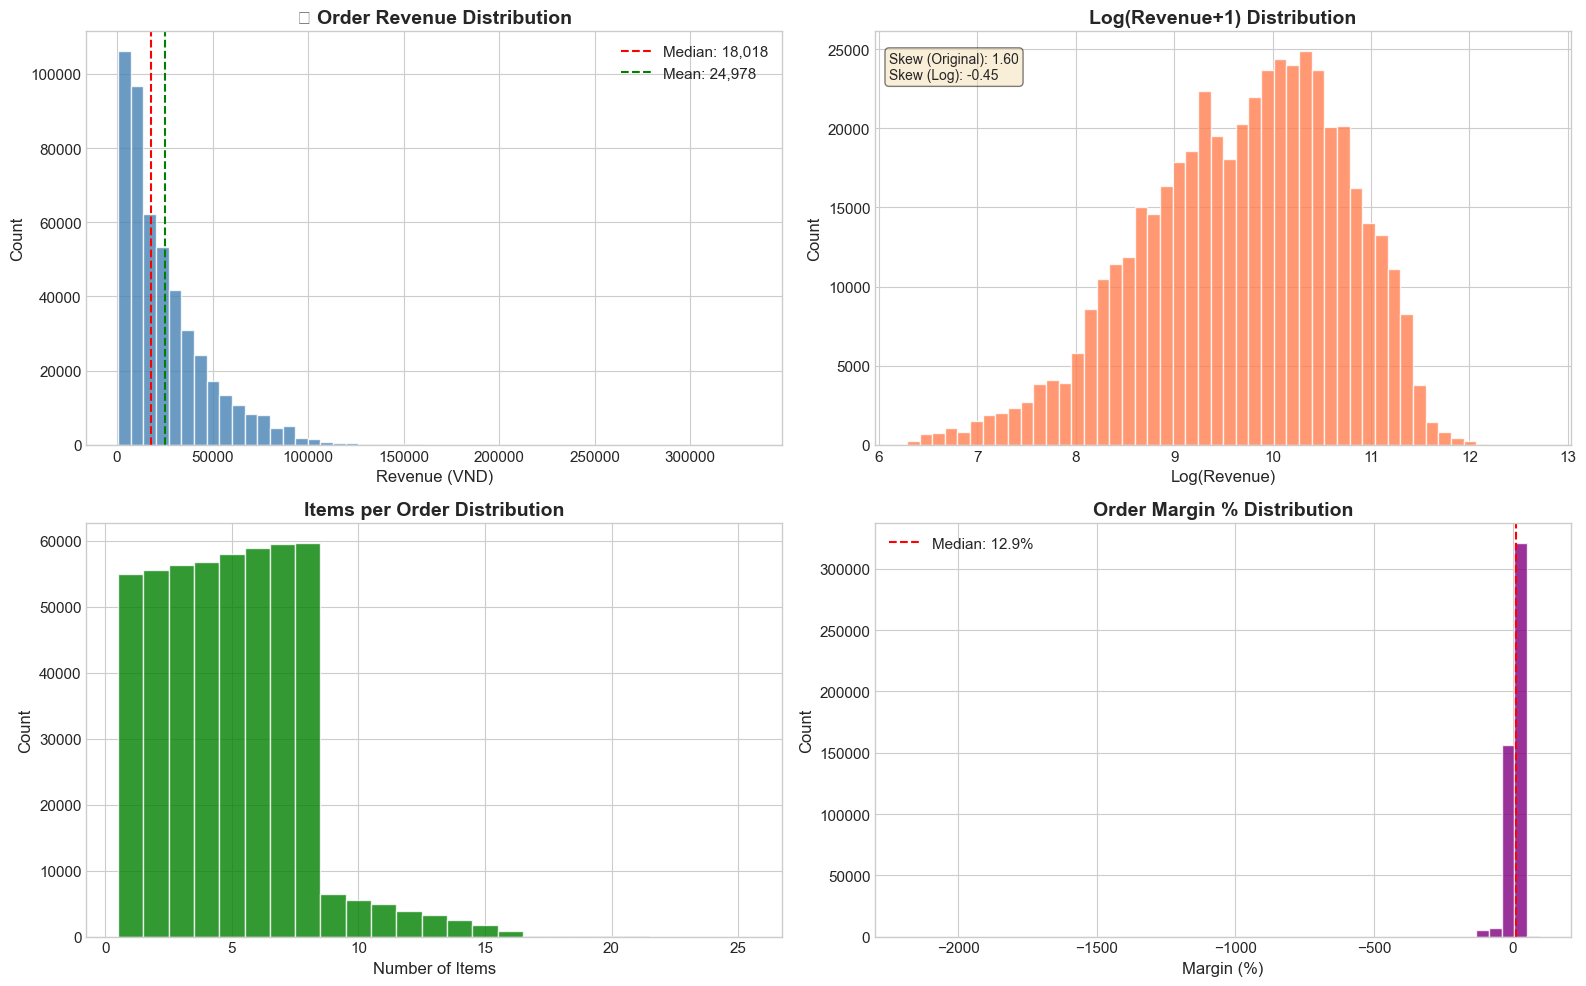


Revenue Distribution Insights:
   Skewness (Original): 1.60 → Right-skewed
   Skewness (Log):      -0.45 → Log transform giúp giảm skew
   → Prescriptive: Nên dùng Log transform cho model


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Revenue distribution
ax = axes[0, 0]
ax.hist(order_revenue['total_revenue'], bins=50, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(order_revenue['total_revenue'].median(), color='red', linestyle='--', 
           label=f'Median: {order_revenue["total_revenue"].median():,.0f}')
ax.axvline(order_revenue['total_revenue'].mean(), color='green', linestyle='--', 
           label=f'Mean: {order_revenue["total_revenue"].mean():,.0f}')
ax.set_title('Order Revenue Distribution', fontweight='bold')
ax.set_xlabel('Revenue (VND)')
ax.set_ylabel('Count')
ax.legend()

# Log Revenue distribution
ax = axes[0, 1]
log_rev = np.log1p(order_revenue['total_revenue'])
ax.hist(log_rev, bins=50, color='coral', alpha=0.8, edgecolor='white')
ax.set_title('Log(Revenue+1) Distribution', fontweight='bold')
ax.set_xlabel('Log(Revenue)')
ax.set_ylabel('Count')

# Skewness info
skew_orig = order_revenue['total_revenue'].skew()
skew_log = log_rev.skew()
ax.text(0.02, 0.95, f'Skew (Original): {skew_orig:.2f}\nSkew (Log): {skew_log:.2f}', 
        transform=ax.transAxes, va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Items per order
ax = axes[1, 0]
ax.hist(order_revenue['n_items'], bins=range(1, order_revenue['n_items'].max()+2), 
        color='green', alpha=0.8, edgecolor='white', align='left')
ax.set_title('Items per Order Distribution', fontweight='bold')
ax.set_xlabel('Number of Items')
ax.set_ylabel('Count')

# Margin % distribution
ax = axes[1, 1]
ax.hist(order_revenue['margin_pct'], bins=50, color='purple', alpha=0.8, edgecolor='white')
ax.axvline(order_revenue['margin_pct'].median(), color='red', linestyle='--', 
           label=f'Median: {order_revenue["margin_pct"].median():.1f}%')
ax.set_title('Order Margin % Distribution', fontweight='bold')
ax.set_xlabel('Margin (%)')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.show()

print(f'\nRevenue Distribution Insights:')
print(f'   Skewness (Original): {skew_orig:.2f} → {"Right-skewed" if skew_orig > 1 else "Moderate" if skew_orig > 0.5 else "Symmetric"}')
print(f'   Skewness (Log):      {skew_log:.2f} → Log transform {"giúp giảm skew" if abs(skew_log) < abs(skew_orig) else "không hiệu quả"}')
print(f'   → Prescriptive: {"Nên dùng Log transform cho model" if abs(skew_log) < 0.5 else "Cân nhắc Box-Cox transform"}')

---
## 5. Order Behavior Analysis

Phân tích hành vi đặt hàng: trạng thái đơn, phương thức thanh toán, thiết bị, kênh.

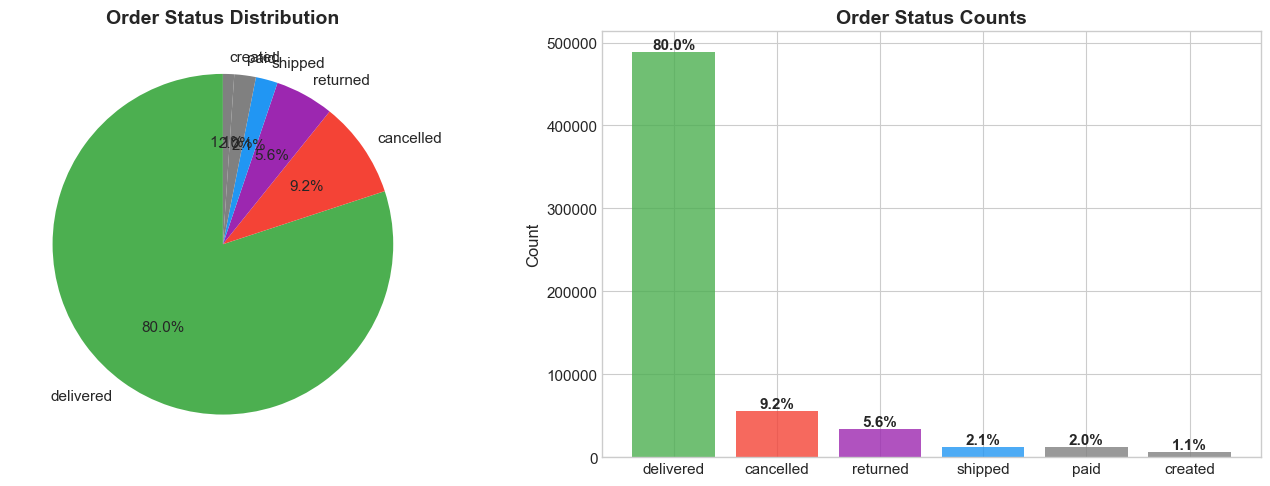


Order Status Summary:
      delivered:  489,028 ( 80.0%)
      cancelled:   56,078 (  9.2%)
       returned:   34,120 (  5.6%)
        shipped:   12,708 (  2.1%)
           paid:   12,487 (  2.0%)
        created:    6,520 (  1.1%)

   Cancel + Return Rate: 14.8%


In [21]:
# === Order Status Distribution ===
status_counts = train_orders['order_status'].value_counts()
status_pct = (status_counts / len(train_orders) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
ax = axes[0]
colors_status = {'delivered': '#4CAF50', 'shipped': '#2196F3', 'pending': '#FFC107', 
                 'cancelled': '#f44336', 'returned': '#9C27B0'}
pie_colors = [colors_status.get(s, 'gray') for s in status_counts.index]
ax.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90, colors=pie_colors)
ax.set_title('Order Status Distribution', fontweight='bold')

# Bar chart
ax = axes[1]
bars = ax.bar(status_counts.index, status_counts.values, 
              color=[colors_status.get(s, 'gray') for s in status_counts.index], alpha=0.8)
ax.set_title('Order Status Counts', fontweight='bold')
ax.set_ylabel('Count')
for bar, pct in zip(bars, status_pct):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            f'{pct}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nOrder Status Summary:')
for status in status_counts.index:
    print(f'   {status:>12}: {status_counts[status]:>8,} ({status_pct[status]:>5.1f}%)')

cancel_rate = status_pct.get('cancelled', 0) + status_pct.get('returned', 0)
print(f'\n   Cancel + Return Rate: {cancel_rate:.1f}%')

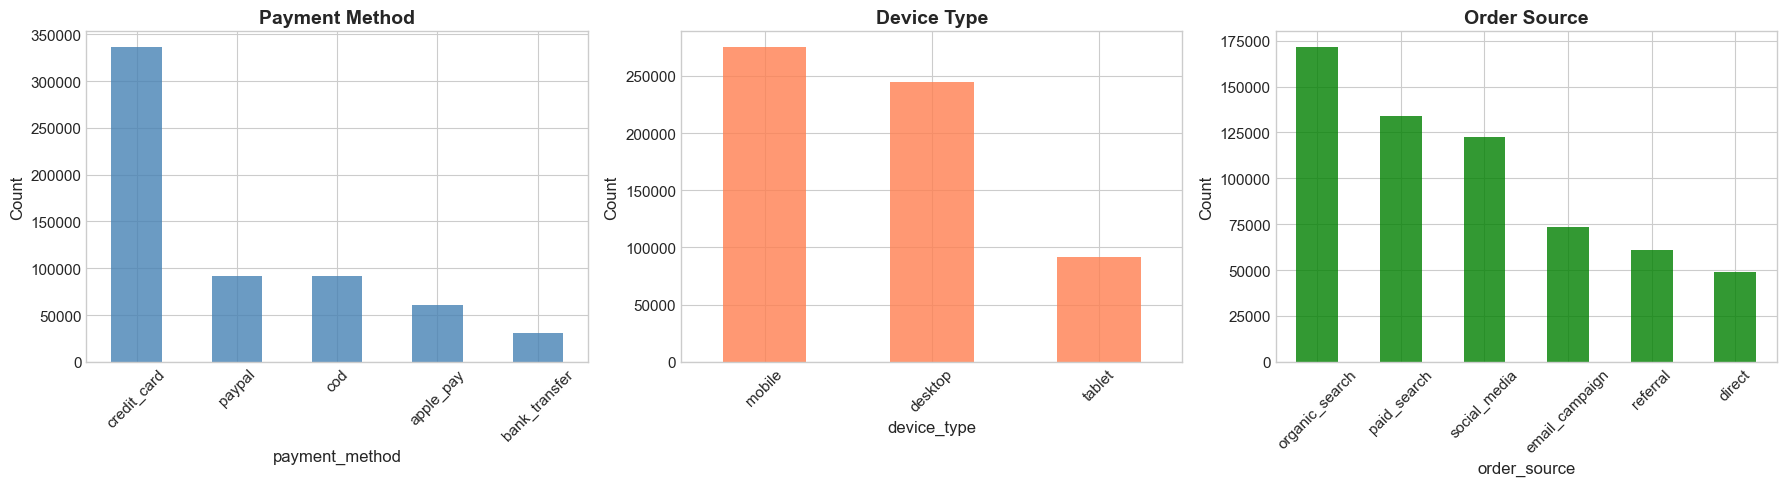

In [22]:
# === Payment & Device & Source Analysis ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Payment method
ax = axes[0]
train_orders['payment_method'].value_counts().plot.bar(ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Payment Method', fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

# Device type
ax = axes[1]
train_orders['device_type'].value_counts().plot.bar(ax=ax, color='coral', alpha=0.8)
ax.set_title('Device Type', fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

# Order source
ax = axes[2]
train_orders['order_source'].value_counts().plot.bar(ax=ax, color='green', alpha=0.8)
ax.set_title('Order Source', fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

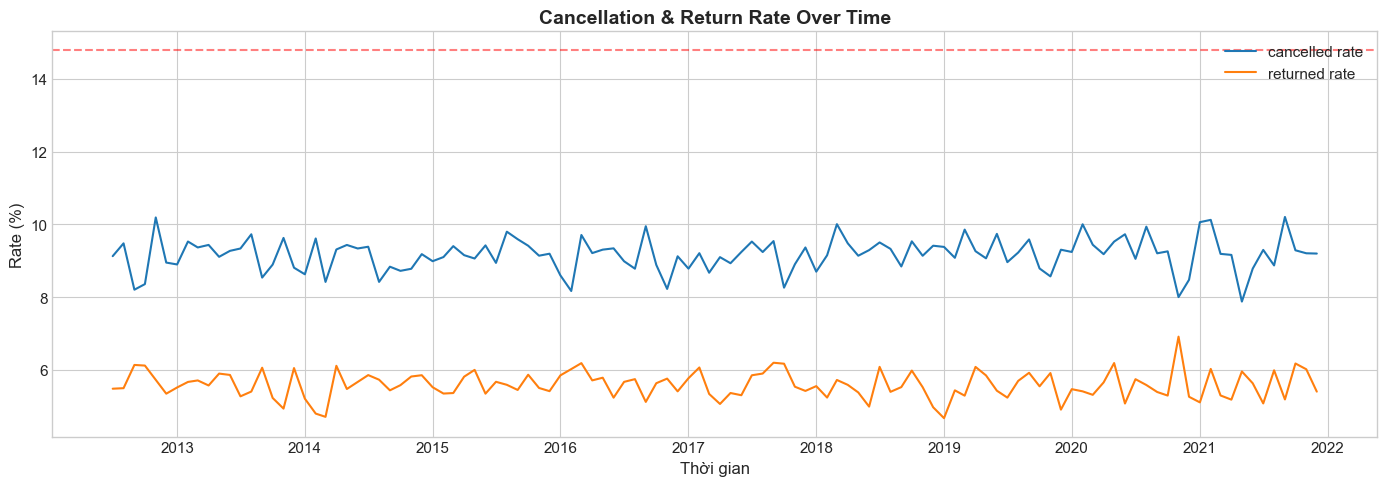

In [23]:
# === Cancel/Return Rate over Time ===
train_orders['year_month'] = train_orders['order_date'].dt.to_period('M')
monthly_status = train_orders.groupby(['year_month', 'order_status']).size().unstack(fill_value=0)
monthly_total = monthly_status.sum(axis=1)

fig, ax = plt.subplots(figsize=(14, 5))

for status in ['cancelled', 'returned']:
    if status in monthly_status.columns:
        rate = (monthly_status[status] / monthly_total * 100)
        ax.plot(rate.index.to_timestamp(), rate.values, label=f'{status} rate', linewidth=1.5)

ax.set_title('Cancellation & Return Rate Over Time', fontweight='bold')
ax.set_xlabel('Thời gian')
ax.set_ylabel('Rate (%)')
ax.legend()
ax.axhline(y=cancel_rate, color='red', linestyle='--', alpha=0.5, label='Overall avg')

plt.tight_layout()
plt.show()

---
## 6. Outlier Detection

Phát hiện giá trị bất thường trong Revenue để đảm bảo chất lượng dữ liệu cho model.

### Phương pháp:
1. **IQR Method:** Conservative, phù hợp phân phối skewed
2. **Z-Score Method:** Phù hợp phân phối gần normal
3. **Domain-specific:** Dựa trên kiến thức nghiệp vụ

In [24]:
def detect_outliers_iqr(series, multiplier=1.5):
    """Detect outliers using IQR method."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    outliers = (series < lower) | (series > upper)
    return outliers, lower, upper

def detect_outliers_zscore(series, threshold=3):
    """Detect outliers using Z-Score method."""
    z_scores = np.abs(stats.zscore(series.dropna()))
    outliers = z_scores > threshold
    return outliers

# === Daily Revenue Outliers ===
print('='*60)
print('OUTLIER DETECTION — Daily Revenue')
print('='*60)

# IQR method
non_zero_rev = daily_revenue[daily_revenue['revenue'] > 0]['revenue']
iqr_outliers, iqr_lower, iqr_upper = detect_outliers_iqr(non_zero_rev)
n_iqr = iqr_outliers.sum()

# Z-Score method
zscore_outliers = detect_outliers_zscore(non_zero_rev)
n_zscore = zscore_outliers.sum()

print(f'\nIQR Method (1.5×IQR):')
print(f'   Lower bound: {iqr_lower:>15,.0f}')
print(f'   Upper bound: {iqr_upper:>15,.0f}')
print(f'   Outliers:    {n_iqr:>5} / {len(non_zero_rev)} ({n_iqr/len(non_zero_rev)*100:.1f}%)')

print(f'\nZ-Score Method (|z| > 3):')
print(f'   Outliers:    {n_zscore:>5} / {len(non_zero_rev)} ({n_zscore/len(non_zero_rev)*100:.1f}%)')

OUTLIER DETECTION — Daily Revenue

IQR Method (1.5×IQR):
   Lower bound:      -1,632,231
   Upper bound:       8,116,391
   Outliers:      147 / 3468 (4.2%)

Z-Score Method (|z| > 3):
   Outliers:       70 / 3468 (2.0%)


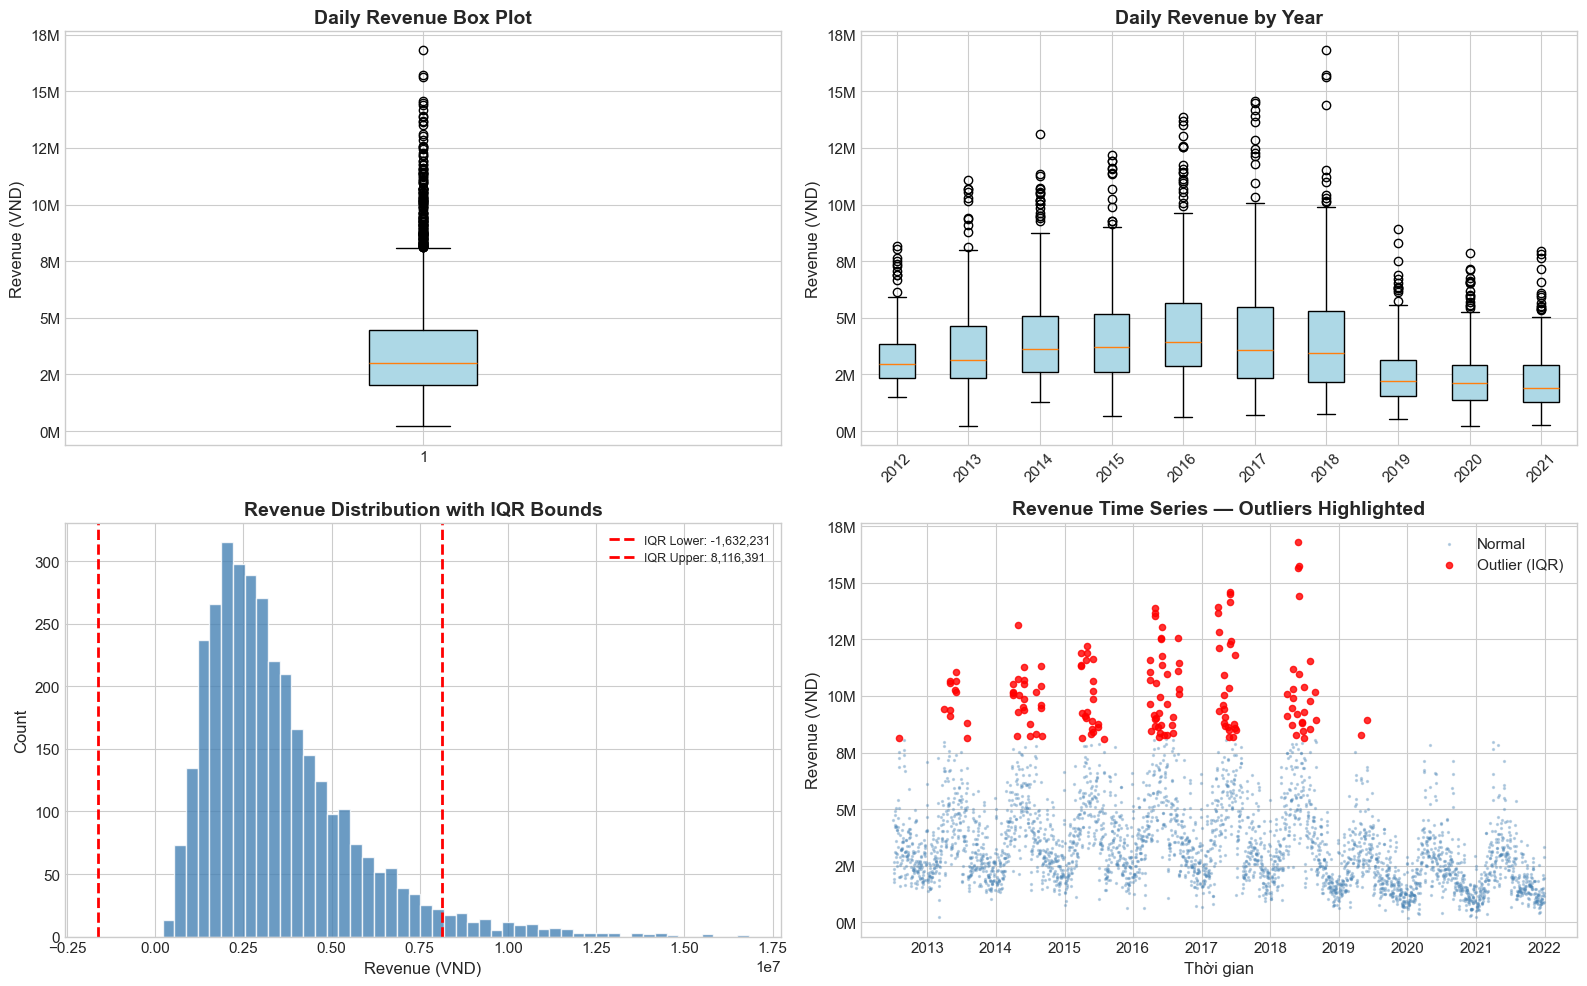

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Box plot - Daily Revenue
ax = axes[0, 0]
bp = ax.boxplot(non_zero_rev.values, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
ax.set_title('Daily Revenue Box Plot', fontweight='bold')
ax.set_ylabel('Revenue (VND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# Box plot by Year
ax = axes[0, 1]
yearly_data = [daily_revenue[daily_revenue['year'] == y]['revenue'].values 
               for y in sorted(daily_revenue['year'].unique())]
bp = ax.boxplot(yearly_data, labels=sorted(daily_revenue['year'].unique()), patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.set_title('Daily Revenue by Year', fontweight='bold')
ax.set_ylabel('Revenue (VND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.tick_params(axis='x', rotation=45)

# Histogram with outlier bounds
ax = axes[1, 0]
ax.hist(non_zero_rev, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(iqr_lower, color='red', linestyle='--', linewidth=2, label=f'IQR Lower: {iqr_lower:,.0f}')
ax.axvline(iqr_upper, color='red', linestyle='--', linewidth=2, label=f'IQR Upper: {iqr_upper:,.0f}')
ax.set_title('Revenue Distribution with IQR Bounds', fontweight='bold')
ax.set_xlabel('Revenue (VND)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

# Time series with outliers highlighted
ax = axes[1, 1]
rev_with_flag = daily_revenue[daily_revenue['revenue'] > 0].copy()
rev_with_flag['is_outlier'] = iqr_outliers.values if len(iqr_outliers) == len(rev_with_flag) else False
normal = rev_with_flag[~rev_with_flag['is_outlier']]
outlier = rev_with_flag[rev_with_flag['is_outlier']]
ax.scatter(normal['date'], normal['revenue'], s=2, c='steelblue', alpha=0.3, label='Normal')
ax.scatter(outlier['date'], outlier['revenue'], s=20, c='red', alpha=0.8, label='Outlier (IQR)', zorder=5)
ax.set_title('Revenue Time Series — Outliers Highlighted', fontweight='bold')
ax.set_xlabel('Thời gian')
ax.set_ylabel('Revenue (VND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.legend()

plt.tight_layout()
plt.show()

In [26]:
# === Order-level Outliers ===
print('='*60)
print('OUTLIER DETECTION — Order Value')
print('='*60)

order_iqr_outliers, order_lower, order_upper = detect_outliers_iqr(order_revenue['total_revenue'])
n_order_outliers = order_iqr_outliers.sum()

print(f'\nIQR Method (1.5×IQR):')
print(f'   Lower bound: {order_lower:>15,.0f}')
print(f'   Upper bound: {order_upper:>15,.0f}')
print(f'   Outliers:    {n_order_outliers:>5} / {len(order_revenue)} ({n_order_outliers/len(order_revenue)*100:.1f}%)')

# Show outlier orders
if n_order_outliers > 0:
    outlier_orders = order_revenue[order_iqr_outliers].sort_values('total_revenue', ascending=False)
    print(f'\nTop 10 Outlier Orders (by Revenue):')
    display(outlier_orders[['order_id', 'total_revenue', 'n_items', 'total_discount', 'margin_pct']].head(10))

OUTLIER DETECTION — Order Value

IQR Method (1.5×IQR):
   Lower bound:         -31,952
   Upper bound:          74,868
   Outliers:    22091 / 489028 (4.5%)

Top 10 Outlier Orders (by Revenue):


,order_id,total_revenue,n_items,total_discount,margin_pct
401764,645732,331570.40,8,0.00,6.137580
392904,631538,302124.08,8,30212.41,-3.010657
391782,629691,299060.24,8,29906.02,-4.065990
376479,605128,250034.88,6,0.00,6.647025
350390,563097,246463.20,6,0.00,5.294178
443903,713659,217184.38,13,0.00,31.948056
362597,582948,206329.76,8,0.00,7.189317
385157,619091,205516.40,5,0.00,5.354269
349097,561096,202730.80,5,0.00,4.053799
352619,566739,202216.96,8,0.00,5.301682


#### Outlier Handling Strategy

| Approach | Khi nào dùng | Risk |
|----------|-------------|------|
| **Keep** | Outlier là giá trị thực (big orders) | Model bị ảnh hưởng bởi extreme values |
| **Cap (Winsorize)** | Giảm ảnh hưởng nhưng giữ thông tin | Mất thông tin extreme |
| **Remove** | Outlier là lỗi dữ liệu | Mất dữ liệu hợp lệ |
| **Log Transform** | Giảm skewness tự nhiên | Phải inverse transform khi predict |

> **Prescriptive:** Qua phương pháp phát hiện, ta thấy có khoảng **4.2%** số ngày (theo IQR method với ngưỡng > 8.1 triệu) và **2.0%** số ngày (Z-Score > 3) là Outliers mang giá trị doanh thu cao bất thường. Vì outliers chiếm tỷ lệ nhỏ nhưng có mức chênh lệch lớn so với trung vị, khuyến nghị sử dụng phương pháp **Cap (Winsorize)** (cắt bỏ phần đuôi tại mức `iqr_upper_bound` hoặc Percentile thứ 98-99). Giải pháp này giúp các thuật toán dự báo (đặc biệt là Regression/ARIMA) không bị lệch chuẩn bởi nhiễu cực đoan, đồng thời giữ lại tín hiệu về những ngày "peak sales" của hệ thống. Ngoài ra, có thể cân nhắc thêm **Log Transform** để giảm độ lệch phải (skewness).


#### Target Variable (Revenue)
| Property | Finding | Action |
|----------|---------|--------|
| **Trend** | Doanh thu đạt đỉnh 2016, giảm mạnh trong 2019 (-38.8%) và suy giảm nhẹ/đi ngang sau đó. Trend strength rất mạnh (`0.7143`). Điểm gãy trend (structural break) xảy ra ở 2018-2019. | Đảm bảo giải quyết bài toán non-stationary bằng Detrending / Differencing bậc cao. Các mô hình bắt trọng số cao cho dữ liệu lịch sử gần nhất sẽ hoạt động tốt hơn. |
| **Seasonality** | Tính mùa vụ hàng năm rõ rệt theo chu kỳ 12 tháng: đỉnh điểm (peak) vào Tháng 5, chạm đáy vào Tháng 1. Độ mạnh (Seasonal strength) cao (`0.8297`). | Các mô hình bắt buộc phải có thành phần kiểm soát mùa vụ (như SARIMA có chu kỳ hoặc Prophet với Yearly Seasonality). |
| **Stationarity** | Chuỗi doanh thu ban đầu không dừng (**Non-Stationary**) (Reject cả ADF & KPSS). Chỉ vượt qua điểm dừng an toàn sau khi differencing bậc 2 (D=2). | Nếu sử dụng họ ARIMA, tham số bậc tích hợp (vi phân) `d` có thể sẽ cần thiết lập ở mức `d=1` hoặc `d=2`. |
| **Distribution** | Lệch phải (Right-skewed) cực lớn ở cấp độ đơn hàng. Mean doanh thu (24.9k) lớn hơn nhiều so với Median (18.0k). Biên lợi nhuận trung bình khá mỏng (~13%). | Cân nhắc quy hoạch dữ liệu bằng **Log Transform** (`log(X+1)`) làm ổn định phương sai trước khi training, sau đó Inverse Transform giá trị khi dự báo thực. |
| **Outliers** | Một lượng ngày nhất định (~4.2%) phá vỡ ngưỡng phân phối quy chuẩn của Boxplot, mang về dòng tiền doanh thu đột biến có thể do Big Sales / Gom sỉ. | Đối với Regression Models, cần áp dụng **Winsorize** (Cap Outliers) để tránh nhiễu do điểm ngoại lai. Nên khai báo các biến ngày lễ/event để mô hình "học" được lý do gây đột biến. |

#### Model Recommendations
1. **Classical Time Series & Baseline Models:** 
   * Dựa vào biểu đồ phân tích **ACF/PACF** có các đợt tăng vọt lặp lại sau mỗi 12 độ trễ, **SARIMA** (với tham số gốc `s=12`, `d=1` hoặc `d=2`) sẽ là lựa chọn kinh điển, tuyến tính và ổn định để tạo baseline dự báo hàng tháng/hàng tuần.
2. **Advanced Structural Models:** 
   * **Prophet** (của Meta) là lựa chọn cực kỳ sáng giá. Thuật toán này cho phép xác lập cấu trúc điểm gãy rẽ xu hướng (*changepoints*) để handle cú sập doanh thu 2019, đồng thời bắt cực tốt các nhiễu mùa vụ ở tầng Week/Month.
3. **Machine Learning / Ensemble Models:** 
   * **LightGBM / XGBoost:** Các thuật toán dạng cây này khi kết hợp với Time-Based Features (Day-of-Week, Tháng, Quý) cùng Lagging/Rolling Window có năng lực xử lý cực tốt những tập dữ liệu có hành vi phức tạp, có ngoại lai và không đòi hỏi quy chuẩn phân phối nghiêm ngặt như ARIMA.

> **Trạng thái:** Hoàn tất phân tích dữ liệu đơn biến. Bước tiếp theo ta sẽ đi sâu vào mối tương quan đa biến và thiết kế đặc trưng (Feature Engineering) cho bộ dữ liệu.
